# Employee Attrition Prediction Using Machine Learning

## 1. Introduction

Employee attrition refers to the situation where employees leave an organization.
Predicting employee attrition can help organizations identify employees who may
be at risk of leaving and understand the factors associated with employee turnover.

In this project, machine learning techniques are used to analyze employee data
and predict whether an employee is likely to leave the organization.

The project follows a research-oriented approach. Instead of blindly applying
preprocessing and machine learning techniques, the dataset is investigated at
each stage. If a problem is identified, suitable methods are considered,
experimented with, compared, and the most appropriate method is selected based
on evidence.

The final objective is to develop and evaluate a machine learning model that
can predict employee attrition on previously unseen data.

In [3]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###  Importing Required Libraries

In this section, the basic Python libraries required for data loading,
inspection, numerical analysis, and visualization are imported.

Pandas is used for handling tabular data, NumPy is used for numerical
operations, and Matplotlib and Seaborn are used for data visualization.

Only the libraries required at this stage are imported. Machine learning
libraries will be imported later when model development begins.

In [5]:
df = pd.read_csv(r"C:\Users\lksch\OneDrive\Documents\OneDrive\Desktop\MLOPS ASSIGNMENT\WA_Fn-UseC_-HR-Employee-Attrition.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


###  Loading the Dataset

The employee dataset is loaded into a Pandas DataFrame.

The dataset is the primary source of information for this study, so the first
step is to load it and inspect its structure before performing any
preprocessing.

No changes are made to the data at this stage.

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1470
Number of columns: 35


### Understanding the Size of the Dataset

The shape of the dataset is checked to determine the number of observations
(rows) and variables (columns).

Understanding the dataset size is important because it gives an initial idea
about the amount of information available for model development.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [8]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical variables:", len(numerical_columns))
print("\nNumerical Variables:")
print(list(numerical_columns))

Number of numerical variables: 26

Numerical Variables:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## Numerical Variable Analysis

Numerical variables are analyzed to understand their statistical properties, distributions, and possible extreme values.

The analysis includes:
- Descriptive statistics
- Distribution of numerical variables
- Detection of potential outliers using boxplots

This helps in understanding the numerical features before data preprocessing and model development.

In [9]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


### Descriptive Statistics of Numerical Variables

Descriptive statistics are used to understand the central tendency and spread of numerical variables.

Measures such as mean, standard deviation, minimum, maximum, and quartiles are examined.

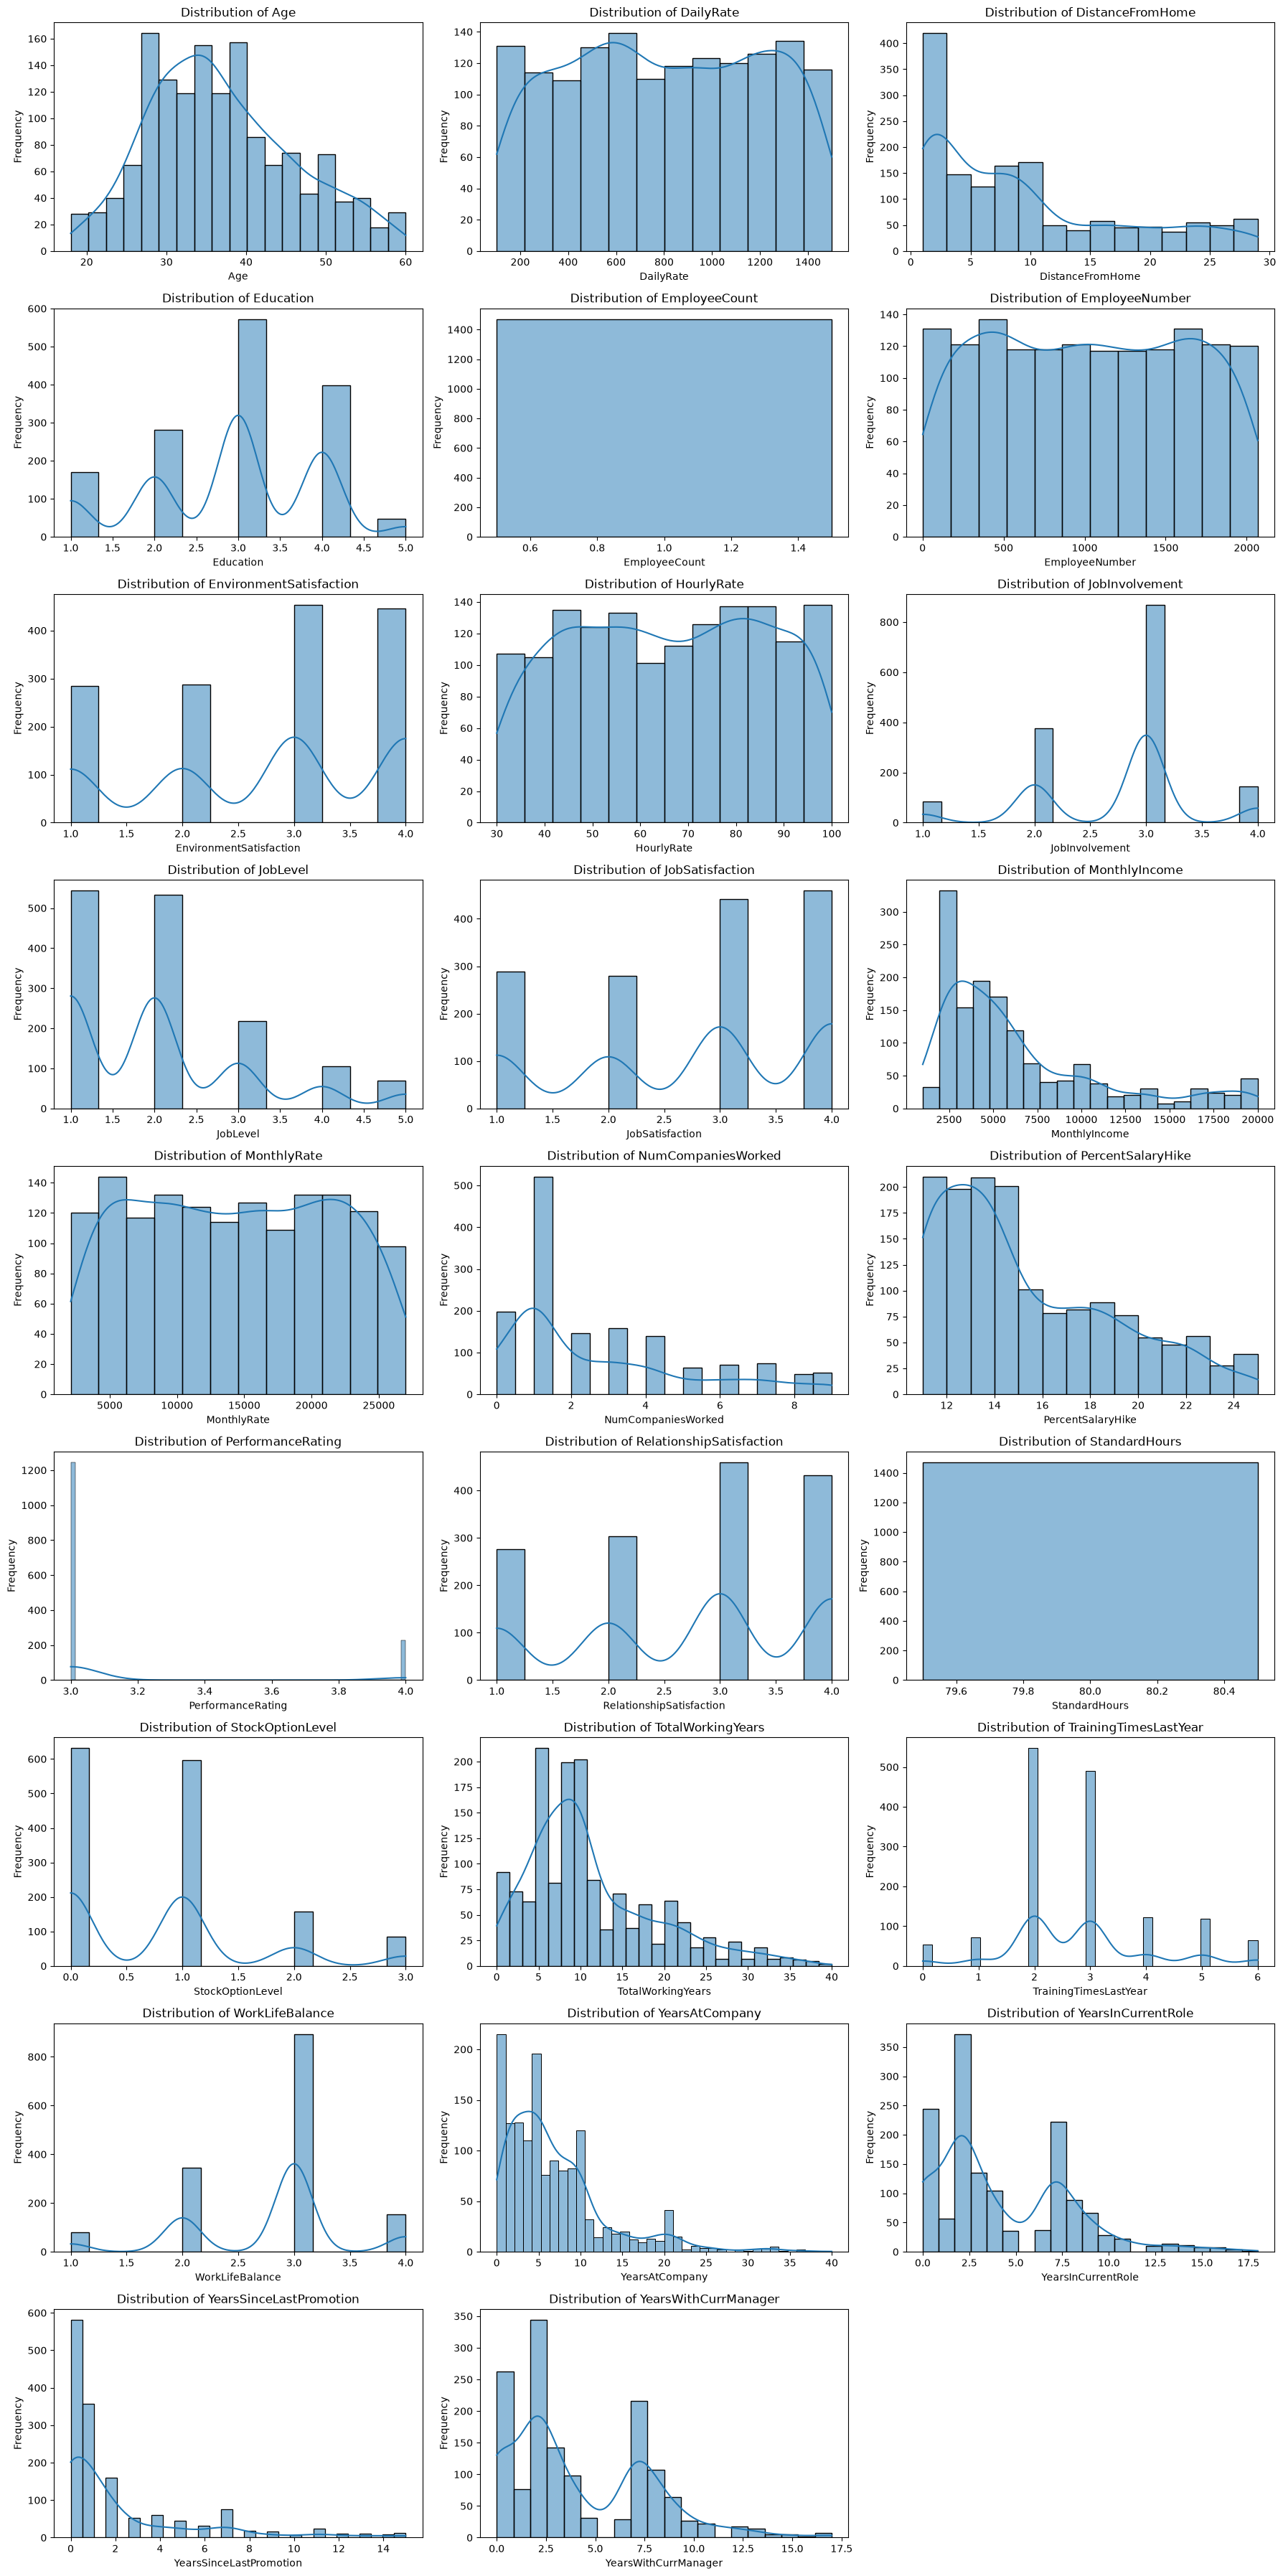

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sns.histplot(data=df, x=column, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribution of Numerical Variables

Histograms are used to examine the distribution of numerical variables.

They help identify:
- Skewed distributions
- Concentration of observations
- Possible unusual patterns

In [11]:
categorical_columns = df.select_dtypes(include=["object"]).columns

df[categorical_columns].describe().T

C:\Users\lksch\AppData\Local\Temp\ipykernel_12584\3947122041.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


## Descriptive Statistics of Categorical Variables

Descriptive statistics for categorical variables are used to understand the number of unique categories, the most frequent category, and its frequency.

This helps identify dominant categories and understand the overall distribution of categorical variables.

In [12]:
for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Category Frequencies: {column}")
    print(f"{'='*50}")
    print(df[column].value_counts())


Category Frequencies: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Category Frequencies: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Category Frequencies: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Category Frequencies: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Category Frequencies: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Category Frequencies: JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Resea

### Category Frequencies

The frequency of each category is examined for every categorical variable.

This provides a detailed view of how observations are distributed across the different categories.

##EXPLORATORY DATA ANALYSIS (EDA)

 Comparison of Mean and Median

The mean and median are compared for each numerical variable to understand
the central tendency of the data.

The mean can be influenced by extreme observations, while the median is more
robust to extreme values. Therefore, comparing both measures can provide an
initial indication of possible skewness or unusual observations.

However, a difference between the mean and median does not automatically
confirm the presence of outliers. Further investigation using skewness,
IQR, and boxplots will be performed before making any decision.

In [13]:
mean_median = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median()
})

mean_median["Difference"] = (
    mean_median["Mean"] - mean_median["Median"]
)

mean_median

,Mean,Median,Difference
Age,36.923810,36.0,0.923810
DailyRate,802.485714,802.0,0.485714
DistanceFromHome,9.192517,7.0,2.192517
Education,2.912925,3.0,-0.087075
EmployeeCount,1.000000,1.0,0.000000
EmployeeNumber,1024.865306,1020.5,4.365306
EnvironmentSatisfaction,2.721769,3.0,-0.278231
HourlyRate,65.891156,66.0,-0.108844
JobInvolvement,2.729932,3.0,-0.270068
JobLevel,2.063946,2.0,0.063946


### Observation

The mean and median values are compared for each numerical variable.

Variables with a large difference between their mean and median will be
investigated further for possible skewness or extreme observations.

At this stage, no observations are removed because the difference between
mean and median alone is not sufficient evidence for outlier removal.

##  Skewness Investigation

Skewness is calculated to understand the shape and symmetry of the numerical
variable distributions.

A skewness value close to 0 generally indicates a relatively symmetric
distribution.

A positive value indicates right-skewness, while a negative value indicates
left-skewness.

Skewness is investigated because highly skewed variables may contain extreme
values and may influence some machine learning algorithms.

However, skewness alone is not sufficient to classify an observation as an
outlier. Therefore, potential outliers will be investigated further using
the IQR method and boxplots before deciding on any treatment.

In [14]:
skewness = df[numerical_columns].skew()

skewness = skewness.sort_values()

skewness

WorkLifeBalance            -0.552480
JobInvolvement             -0.498419
JobSatisfaction            -0.329672
EnvironmentSatisfaction    -0.321654
RelationshipSatisfaction   -0.302828
Education                  -0.289681
HourlyRate                 -0.032311
DailyRate                  -0.003519
EmployeeCount               0.000000
StandardHours               0.000000
EmployeeNumber              0.016574
MonthlyRate                 0.018578
Age                         0.413286
TrainingTimesLastYear       0.553124
PercentSalaryHike           0.821128
YearsWithCurrManager        0.833451
YearsInCurrentRole          0.917363
DistanceFromHome            0.958118
StockOptionLevel            0.968980
JobLevel                    1.025401
NumCompaniesWorked          1.026471
TotalWorkingYears           1.117172
MonthlyIncome               1.369817
YearsAtCompany              1.764529
PerformanceRating           1.921883
YearsSinceLastPromotion     1.984290
dtype: float64

### Observation

The skewness values are examined to identify numerical variables that are
approximately symmetric, positively skewed, or negatively skewed.

Variables with relatively high absolute skewness will be investigated further.

No outliers are removed based only on skewness because skewness describes the
overall distribution and does not identify individual observations.

The next step is to use the Interquartile Range (IQR) method to identify
potential outlier observations.

## Potential Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers
in the numerical variables.

First, the first quartile (Q1) and third quartile (Q3) are calculated.

IQR = Q3 - Q1

The lower and upper limits are calculated as:

Lower Limit = Q1 - 1.5 × IQR
Upper Limit = Q3 + 1.5 × IQR

Observations outside these limits are considered potential outliers.

The IQR method is selected because it is less affected by extreme values
than methods based on the mean and standard deviation. It is also simple
and easy to interpret.

At this stage, potential outliers are only identified. They will not be
removed immediately because an extreme observation may be a genuine value.
Further investigation will be performed before selecting an appropriate
treatment.

In [15]:
outlier_results = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ).sum()

    outlier_percentage = (
        outlier_count / len(df)
    ) * 100

    outlier_results.append([
        column,
        Q1,
        Q3,
        IQR,
        lower_limit,
        upper_limit,
        outlier_count,
        outlier_percentage
    ])

outlier_table = pd.DataFrame(
    outlier_results,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Lower Limit",
        "Upper Limit",
        "Outlier Count",
        "Outlier Percentage"
    ]
)

outlier_table

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count,Outlier Percentage
0,Age,30.00,43.00,13.00,10.500,62.500,0,0.000000
1,DailyRate,465.00,1157.00,692.00,-573.000,2195.000,0,0.000000
2,DistanceFromHome,2.00,14.00,12.00,-16.000,32.000,0,0.000000
3,Education,2.00,4.00,2.00,-1.000,7.000,0,0.000000
4,EmployeeCount,1.00,1.00,0.00,1.000,1.000,0,0.000000
5,EmployeeNumber,491.25,1555.75,1064.50,-1105.500,3152.500,0,0.000000
6,EnvironmentSatisfaction,2.00,4.00,2.00,-1.000,7.000,0,0.000000
7,HourlyRate,48.00,83.75,35.75,-5.625,137.375,0,0.000000
8,JobInvolvement,2.00,3.00,1.00,0.500,4.500,0,0.000000
9,JobLevel,1.00,3.00,2.00,-2.000,6.000,0,0.000000


### Observation

The IQR analysis identifies variables containing observations outside their
calculated lower and upper limits.

The outlier count and percentage are examined for each numerical variable.

These results represent potential outliers rather than confirmed data errors.
Therefore, the observations will be visually investigated using boxplots
before deciding whether they should be retained, removed, capped, or
transformed.


 Visual Investigation of Potential Outliers

Boxplots are used to visually examine the numerical variables after potential
outliers were identified using the IQR method.

A boxplot shows the median, first and third quartiles, the interquartile range,
and observations that lie beyond the whiskers.

This visual investigation is important because an observation identified by
the IQR rule is not necessarily an incorrect observation. It may represent a
genuine employee with an unusual but valid value.

Therefore, the boxplots are used together with the statistical IQR results
before deciding whether any outlier treatment is required.

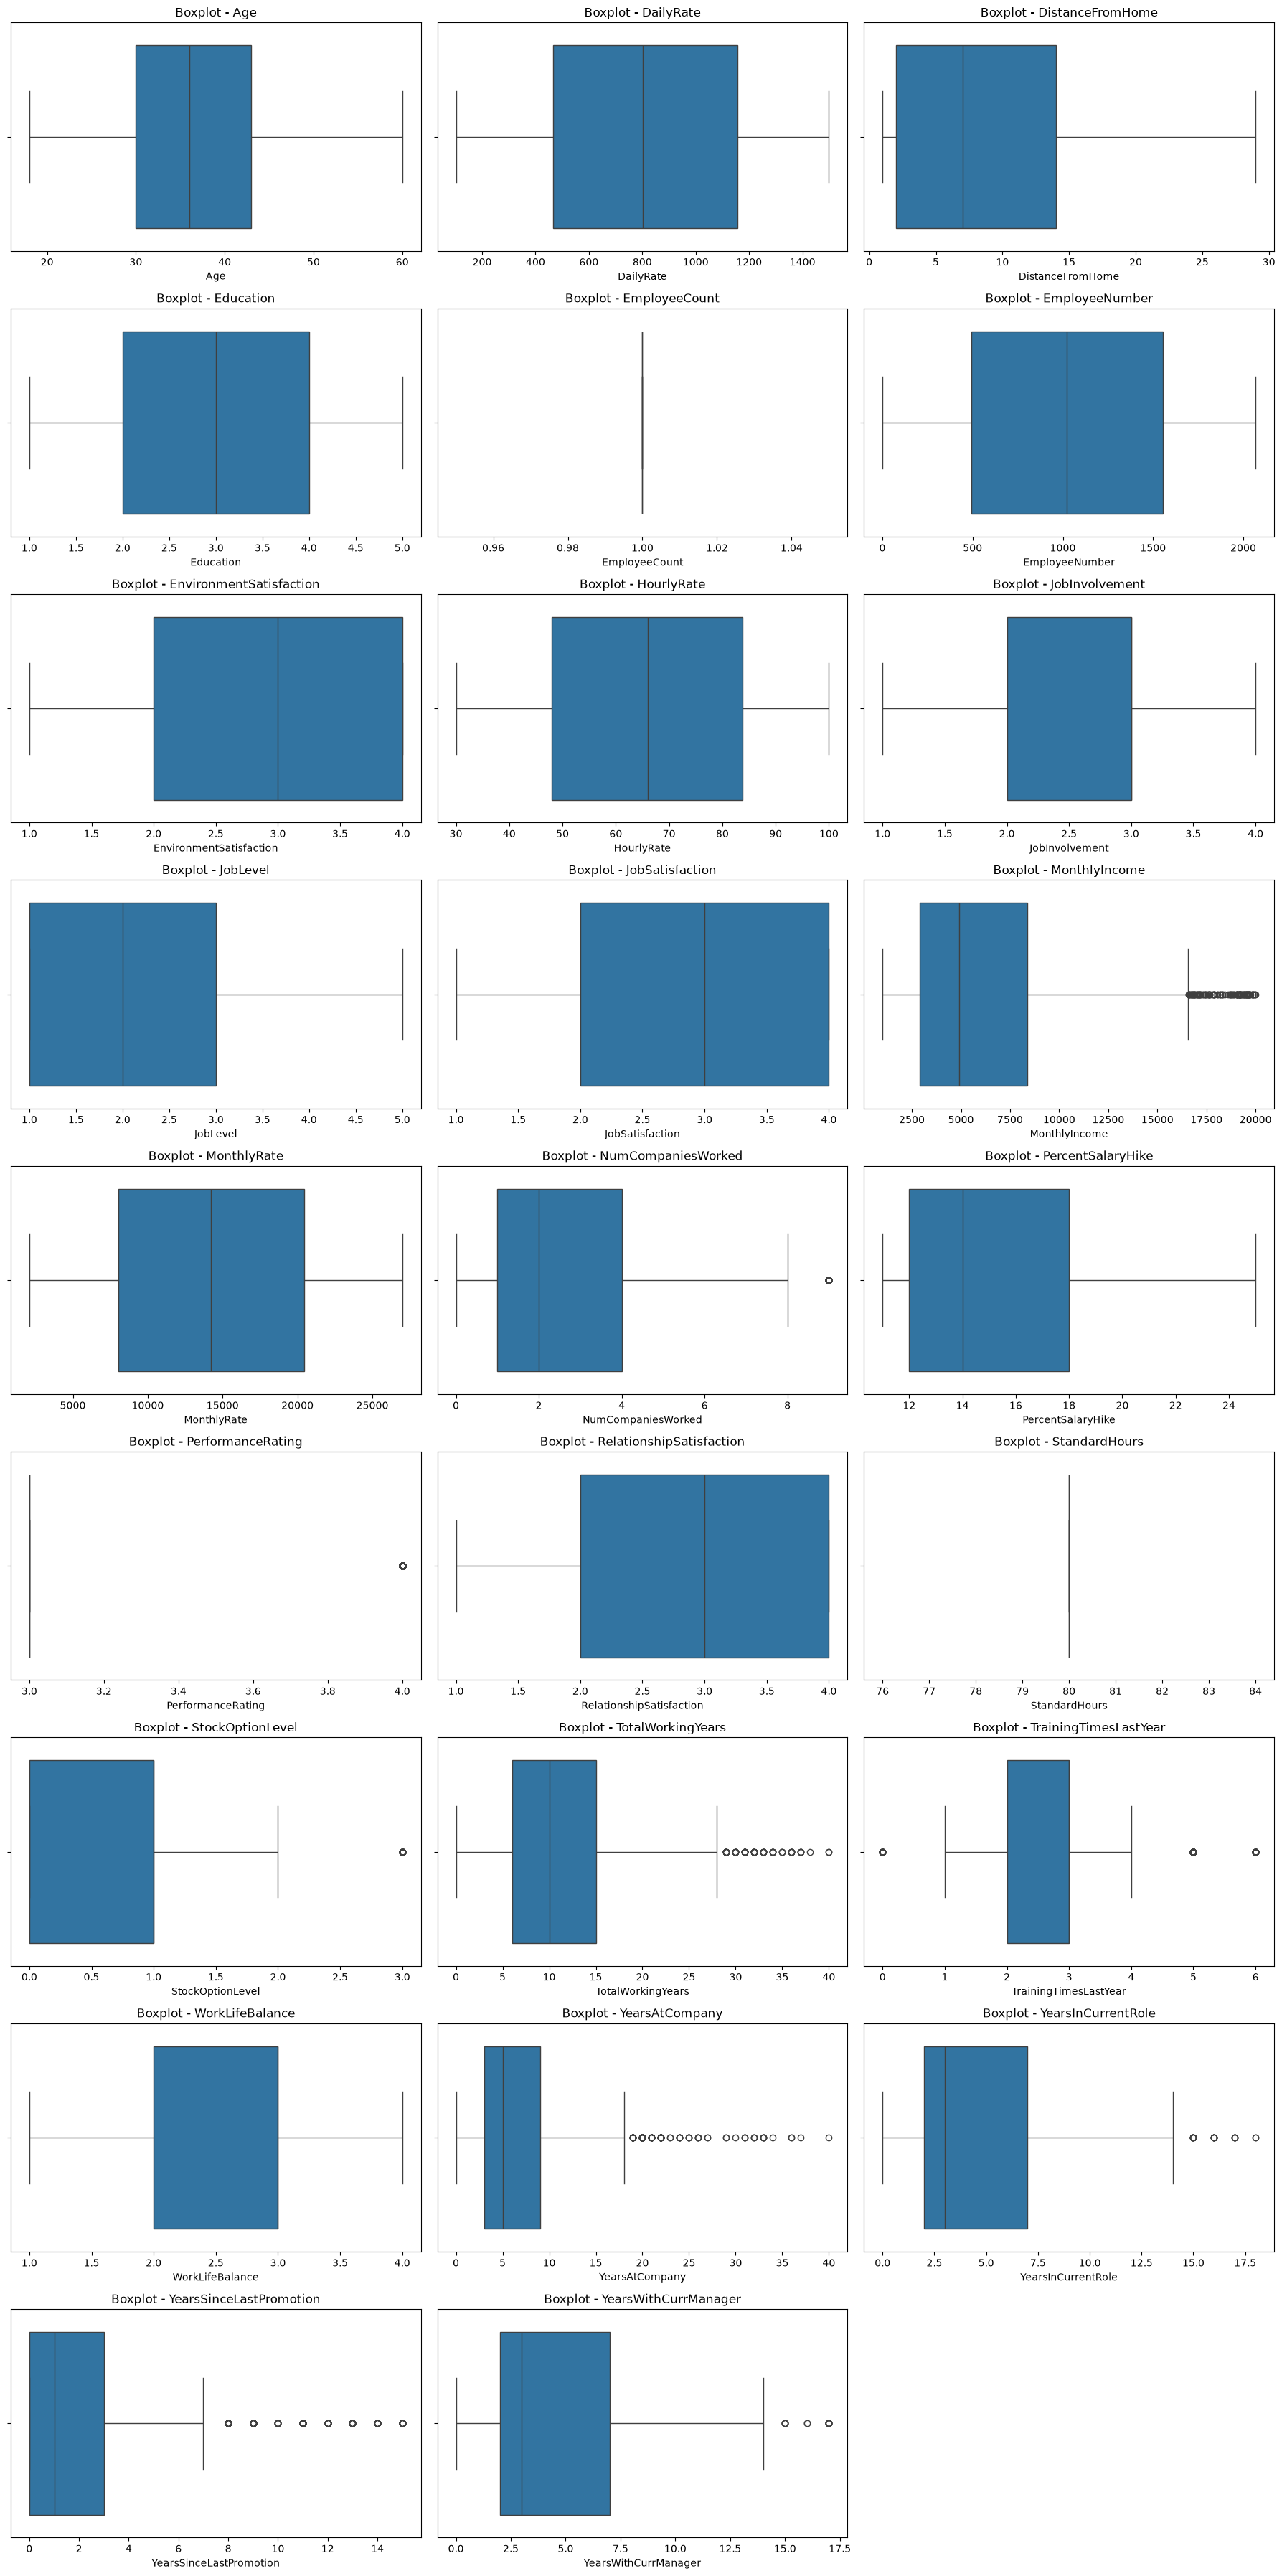

In [16]:
n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, column in enumerate(numerical_columns):

    sns.boxplot(
        x=df[column],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot - {column}")
    axes[i].set_xlabel(column)

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Observation

The boxplots are examined along with the IQR outlier table.

Variables showing observations beyond the whiskers are considered for further
investigation.

The presence of these points does not mean that they should be deleted.
The actual values and their meaning in the dataset must be examined first.

Therefore, the next step is to investigate the actual potential outlier
values before selecting an outlier treatment method.

##  Actual Outlier Investigation

The IQR method identified potential outliers in some numerical variables.
However, an observation outside the IQR limits is not necessarily an
incorrect observation.

Therefore, the actual potential outlier values are investigated before
deciding on any treatment.

This investigation helps determine whether the detected values are:
- genuine extreme observations,
- possible data-entry errors, or
- unusual but valid employee records.

Outliers will not be removed automatically. A suitable treatment will be
selected only after understanding their effect on the dataset.

In [17]:
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ][column]

    if len(outliers) > 0:

        print("\n" + "=" * 60)
        print("Variable:", column)
        print("Outlier Count:", len(outliers))
        print("Lower Limit:", lower_limit)
        print("Upper Limit:", upper_limit)
        print("Minimum Outlier:", outliers.min())
        print("Maximum Outlier:", outliers.max())


Variable: MonthlyIncome
Outlier Count: 114
Lower Limit: -5291.0
Upper Limit: 16581.0
Minimum Outlier: 16595
Maximum Outlier: 19999

Variable: NumCompaniesWorked
Outlier Count: 52
Lower Limit: -3.5
Upper Limit: 8.5
Minimum Outlier: 9
Maximum Outlier: 9

Variable: PerformanceRating
Outlier Count: 226
Lower Limit: 3.0
Upper Limit: 3.0
Minimum Outlier: 4
Maximum Outlier: 4

Variable: StockOptionLevel
Outlier Count: 85
Lower Limit: -1.5
Upper Limit: 2.5
Minimum Outlier: 3
Maximum Outlier: 3

Variable: TotalWorkingYears
Outlier Count: 63
Lower Limit: -7.5
Upper Limit: 28.5
Minimum Outlier: 29
Maximum Outlier: 40

Variable: TrainingTimesLastYear
Outlier Count: 238
Lower Limit: 0.5
Upper Limit: 4.5
Minimum Outlier: 0
Maximum Outlier: 6

Variable: YearsAtCompany
Outlier Count: 104
Lower Limit: -6.0
Upper Limit: 18.0
Minimum Outlier: 19
Maximum Outlier: 40

Variable: YearsInCurrentRole
Outlier Count: 21
Lower Limit: -5.5
Upper Limit: 14.5
Minimum Outlier: 15
Maximum Outlier: 18

Variable: Years

### Observation

The actual values identified as potential outliers are examined along with
their frequency and range.

The presence of extreme values alone is not considered sufficient evidence
for removal. Since employee-related numerical variables can naturally have
wide ranges, genuine extreme observations may contain useful information.

Therefore, the next step is to compare possible outlier treatment methods
and select an appropriate method based on the characteristics of the data.

## Target Variable Analysis

The target variable, Attrition, represents whether an employee has left the
organization.

The distribution of the target classes is examined to understand the
prediction problem and identify whether class imbalance is present.

Class imbalance can affect machine learning models because a model may become
biased toward the majority class.

At this stage, imbalance is only investigated. No balancing technique is
applied yet because balancing should be performed only on the training data
after the train-test split.

In [18]:
print("Attrition Counts:")
print(df["Attrition"].value_counts())

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


### Observation

The frequency of each Attrition class is examined.

If one class has substantially more observations than the other, the target
variable is considered imbalanced.

The minority class is particularly important in employee attrition
prediction because correctly identifying employees who may leave can be
important for the organization.

Further analysis will be performed using percentages before deciding whether
class balancing is necessary.

### Target Percentage Distribution

The percentage distribution of Attrition classes is calculated to understand
the proportion of employees who stayed and employees who left.

Percentages provide a clearer measure of class imbalance than raw counts
because they show the relative contribution of each class to the dataset.

In [19]:
attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Attrition Percentage Distribution:")
print(attrition_percentage)

Attrition Percentage Distribution:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


### Visualization of Target Distribution

A count plot is used to visually compare the two Attrition classes.

Visualization makes it easier to identify whether there is a substantial
difference between the majority and minority classes.

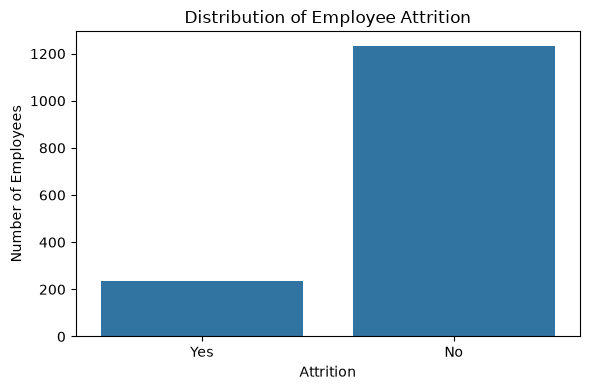

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Attrition")

plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

### Observation

The count plot confirms the distribution of the Attrition classes.

If the difference between the two classes is substantial, class imbalance
should be considered during model development.

However, balancing is not performed at this stage. The test set must remain
representative of unseen data, so any resampling technique will be applied
only to the training data after the train-test split.

## categorical Features vs Attrition

The relationship between categorical employee features and Attrition is
investigated to identify differences in attrition across different groups.

Count plots are used to compare employees who stayed and employees who left
within each category.

This analysis helps identify categorical variables that may have useful
predictive information.

The plots are used for investigation rather than assuming that a visible
difference automatically means that a feature is statistically significant.

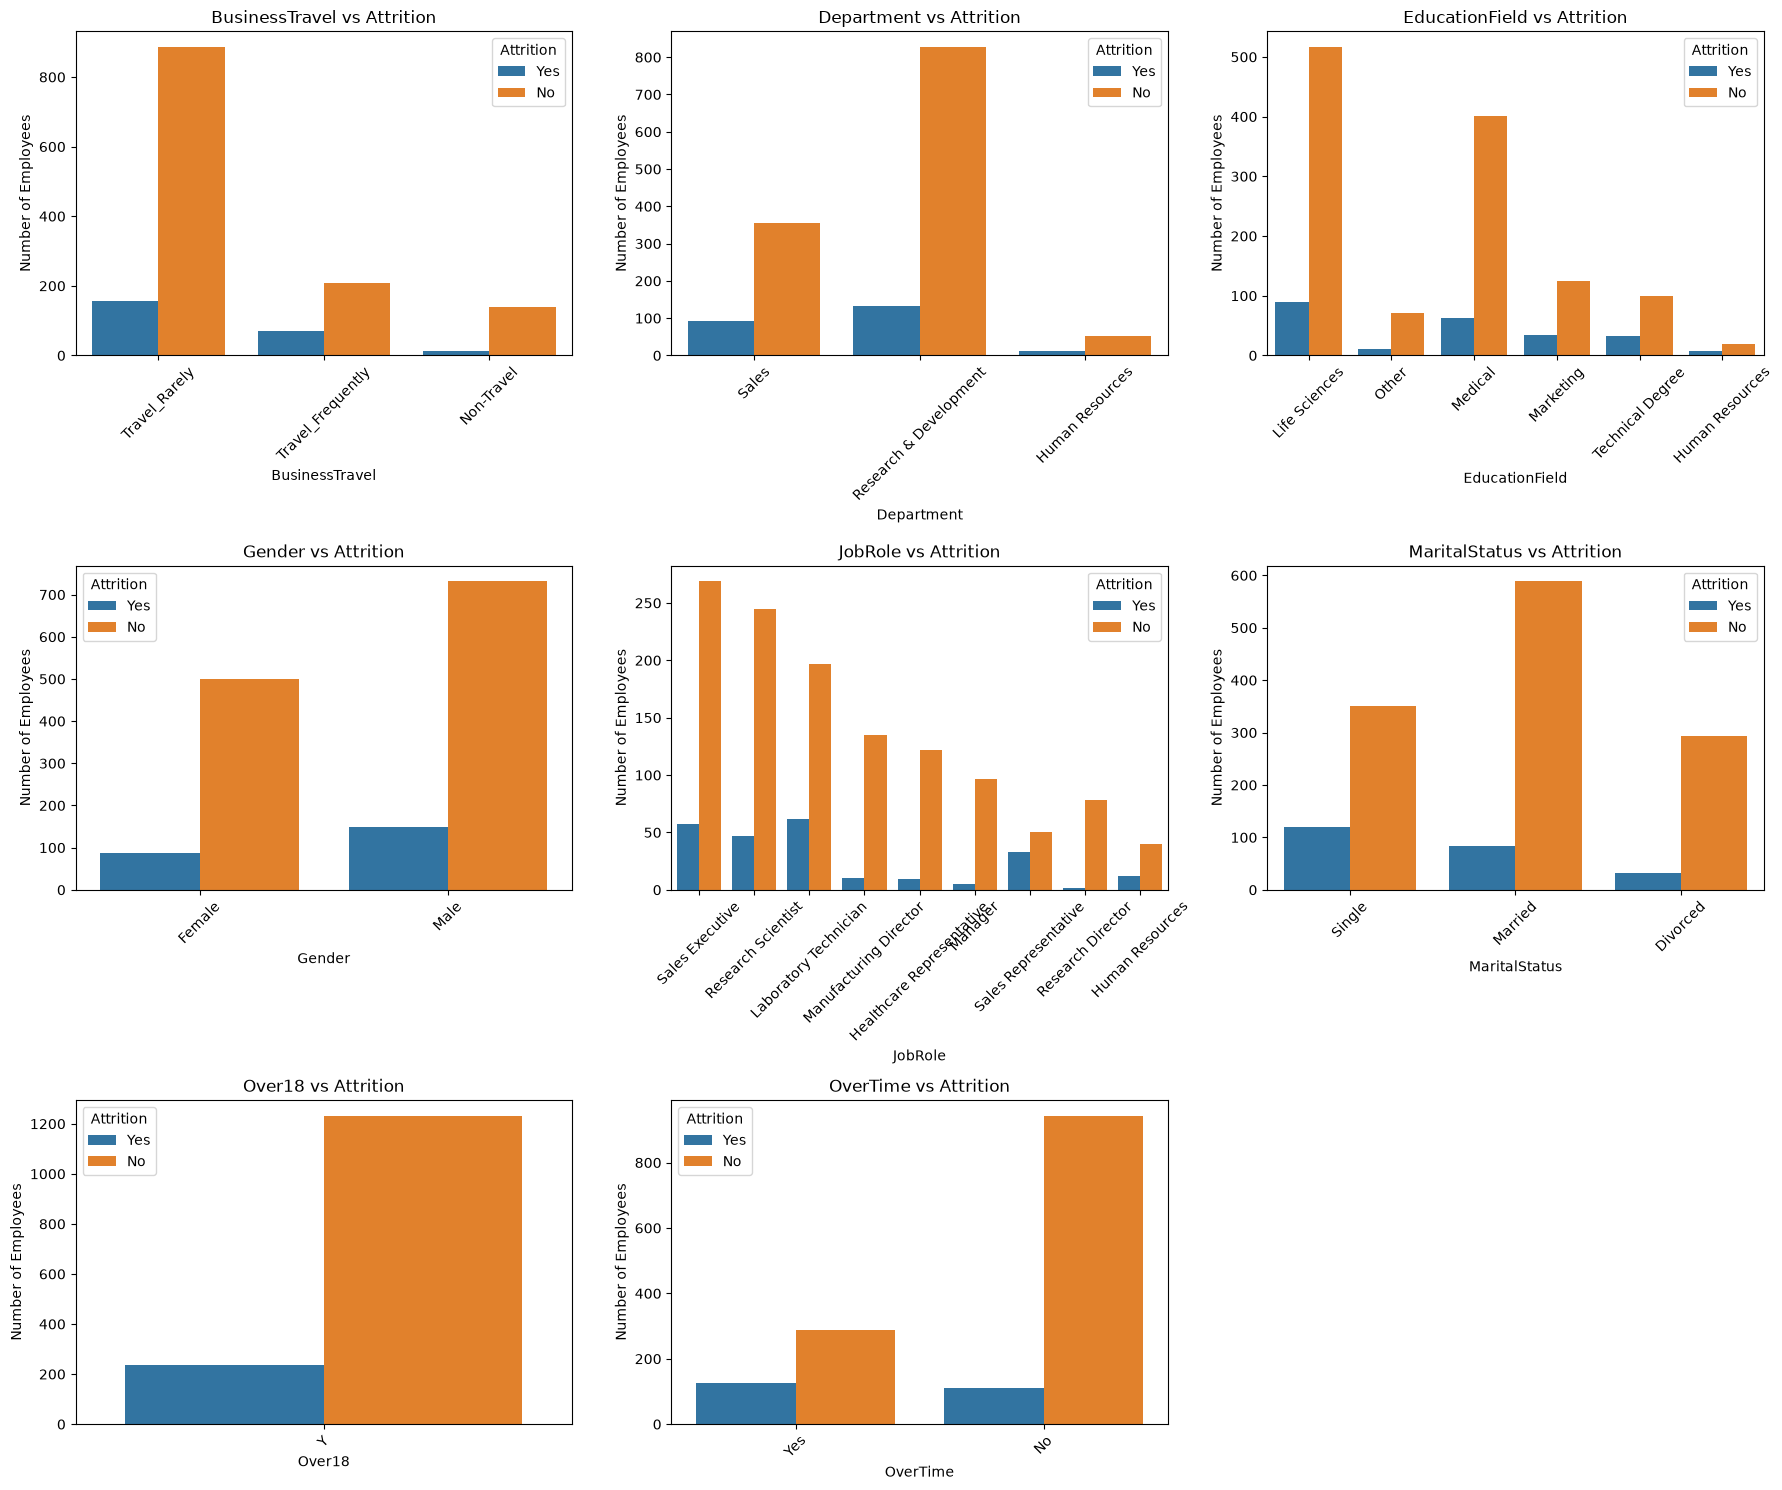

In [21]:
categorical_features = [
    column for column in categorical_columns
    if column != "Attrition"
]

n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, column in enumerate(categorical_features):

    sns.countplot(
        data=df,
        x=column,
        hue="Attrition",
        ax=axes[i]
    )

    axes[i].set_title(f"{column} vs Attrition")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Number of Employees")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(categorical_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Categorical Features and Attrition Distribution

Each categorical variable is visualized against Attrition separately.

Separate plots are used so that the distribution of each feature can be
examined clearly without combining unrelated variables into a single graph.

##  Numerical Features vs Attrition

The relationship between numerical employee features and Attrition is
investigated using boxplots.

Boxplots are used because they allow us to compare the median, spread, and
distribution of each numerical variable between employees who stayed and
employees who left.

Subplots are used so that all numerical variables can be examined in an
organized manner.

This analysis helps identify numerical variables that may contain useful
information for predicting employee Attrition.

The visual differences are treated as observations only and are not used
alone for feature selection.

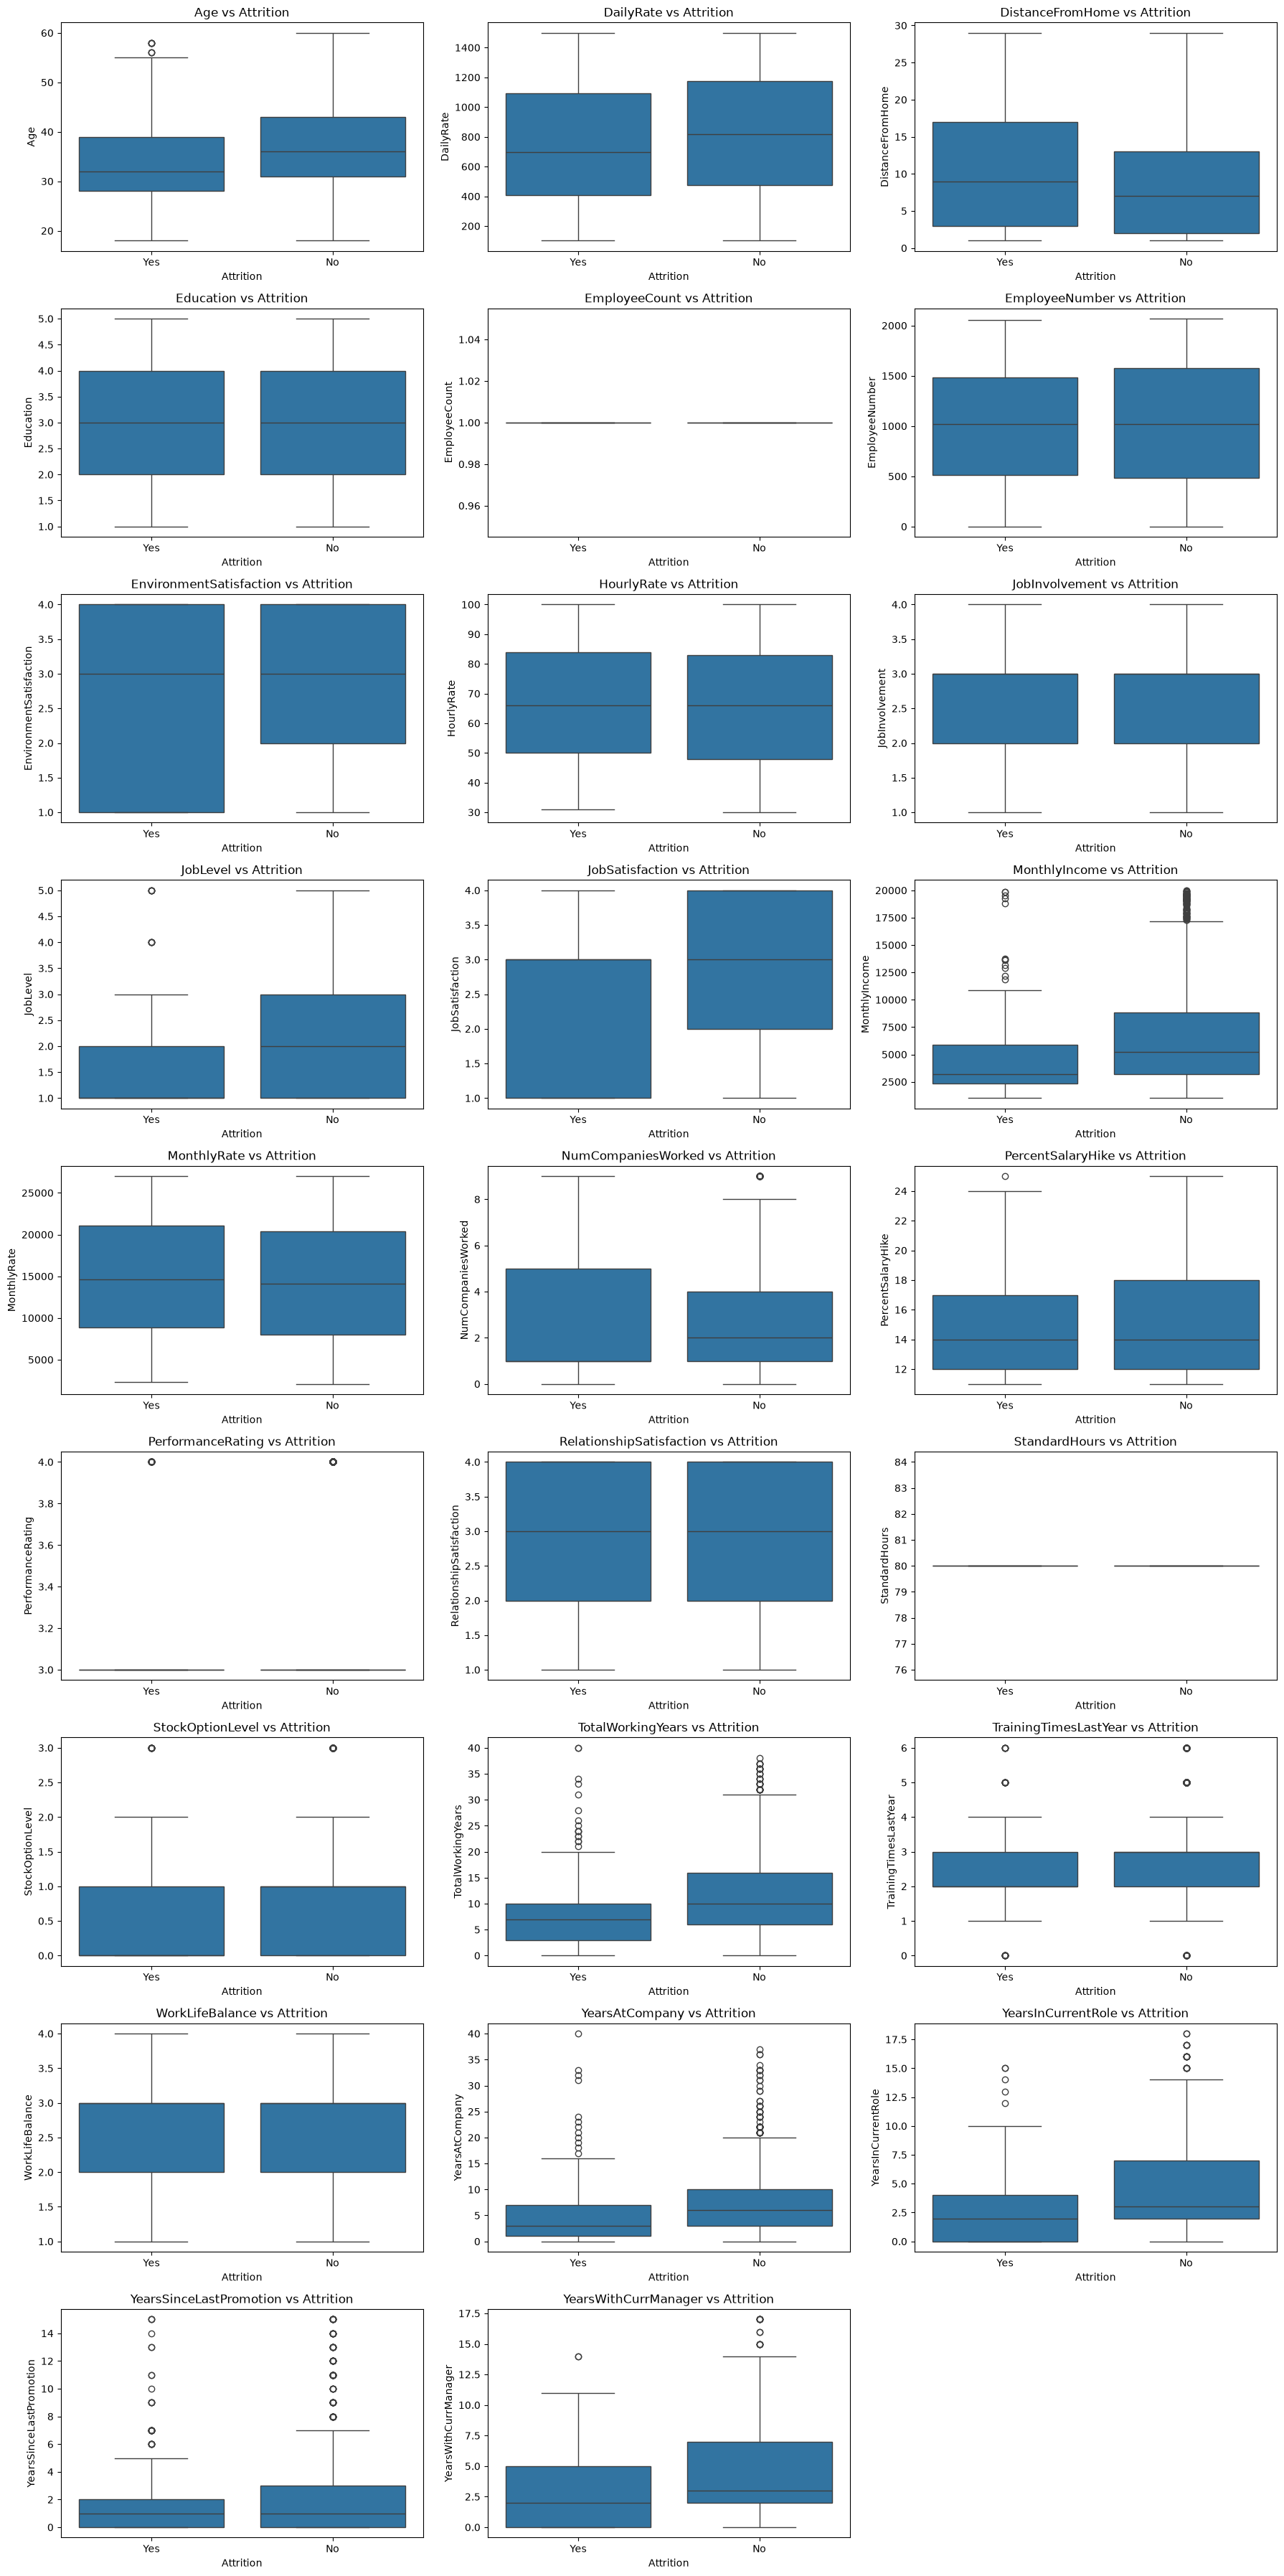

In [22]:
n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for i, column in enumerate(numerical_columns):

    sns.boxplot(
        data=df,
        x="Attrition",
        y=column,
        ax=axes[i]
    )

    axes[i].set_title(f"{column} vs Attrition")
    axes[i].set_xlabel("Attrition")
    axes[i].set_ylabel(column)

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Observation

The boxplots are compared to identify differences in the distributions of
numerical variables between the Attrition classes.

Variables with noticeable differences in their median, spread, or overall
distribution may have a relationship with Attrition.

These observations will be considered during feature engineering and feature
selection. However, no feature is removed based only on the boxplots.

Further analysis will be used before making final feature-selection decisions.

## Data cleaning and Treatment

Duplicate Record Investigation

Duplicate records are checked to determine whether the dataset contains
repeated employee observations.

Duplicate rows can affect statistical analysis and machine learning models
because the same observation may be given more importance than intended.

The duplicates are investigated before removal. If exact duplicate records
are found and there is no reason for them to occur, they can be removed.

In [23]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Observation

The number of exact duplicate rows is examined.

If no duplicates are present, no modification is required.

If duplicates are present, they will be investigated and removed only when
they represent repeated copies of the same observation.

In [24]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Variables with missing values:")
print(missing_values)

Variables with missing values:
Series([], dtype: int64)


##  Complete Missing Value Investigation

Missing values are checked across all variables to ensure that no missing
observations remain unnoticed.

Missing values can cause errors during model training and may reduce the
quality of predictions.

The appropriate treatment depends on the amount and nature of missing data.
Therefore, missing values will not be filled blindly.

## Invalid and Inconsistent Value Investigation

Categorical variables are examined for unexpected or inconsistent category
values.

Examples include spelling differences, unnecessary spaces, or categories
that do not match the expected values.

This check is important because inconsistent categories can create separate
categories during encoding and may affect model learning.

The values are investigated before making any changes.

In [25]:
for column in categorical_columns:

    print("\n" + "=" * 50)
    print("Variable:", column)
    print("=" * 50)

    print(df[column].unique())


Variable: Attrition
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Variable: BusinessTravel
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Variable: Department
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

Variable: EducationField
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

Variable: Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Variable: JobRole
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

Variable: MaritalStatus
<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

Variable: Over18
<StringArr

### Observation

The unique values of each categorical variable are examined for unexpected
or inconsistent categories.

If inconsistent values are found, they will be standardized based on the
meaning of the variable.

If the categories are already consistent, no modification will be applied.


###  Investigation of Capping as an Alternative

Capping limits extreme observations to the calculated IQR boundaries instead
of deleting them.

This method is considered because removing observations can reduce the size
of the dataset and may discard genuine employee information.

Capping is not automatically selected. It will be considered only for
variables where extreme values are valid but may have an excessive influence.

The original data will be preserved so that different approaches can be
compared later.

In [26]:
df_capped = df.copy()

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_capped[column] = df_capped[column].clip(
        lower_limit,
        upper_limit
    )

print("Capped dataset created successfully.")

Capped dataset created successfully.


### Observation

A separate capped version of the dataset has been created without changing
the original dataset.

At this stage, capping is only an experimental treatment. The original and
capped versions can later be compared during model development.

This approach allows the final treatment to be selected based on evidence
rather than assuming that all potential outliers should be removed.

In [27]:
for column in numerical_columns:

    print("\n" + "=" * 50)
    print("Variable:", column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


Variable: Age
Minimum: 18
Maximum: 60

Variable: DailyRate
Minimum: 102
Maximum: 1499

Variable: DistanceFromHome
Minimum: 1
Maximum: 29

Variable: Education
Minimum: 1
Maximum: 5

Variable: EmployeeCount
Minimum: 1
Maximum: 1

Variable: EmployeeNumber
Minimum: 1
Maximum: 2068

Variable: EnvironmentSatisfaction
Minimum: 1
Maximum: 4

Variable: HourlyRate
Minimum: 30
Maximum: 100

Variable: JobInvolvement
Minimum: 1
Maximum: 4

Variable: JobLevel
Minimum: 1
Maximum: 5

Variable: JobSatisfaction
Minimum: 1
Maximum: 4

Variable: MonthlyIncome
Minimum: 1009
Maximum: 19999

Variable: MonthlyRate
Minimum: 2094
Maximum: 26999

Variable: NumCompaniesWorked
Minimum: 0
Maximum: 9

Variable: PercentSalaryHike
Minimum: 11
Maximum: 25

Variable: PerformanceRating
Minimum: 3
Maximum: 4

Variable: RelationshipSatisfaction
Minimum: 1
Maximum: 4

Variable: StandardHours
Minimum: 80
Maximum: 80

Variable: StockOptionLevel
Minimum: 0
Maximum: 3

Variable: TotalWorkingYears
Minimum: 0
Maximum: 40

Variab

### Observation

The minimum and maximum values of the numerical variables are examined to
identify values that may be logically invalid.

An extreme value is not automatically treated as invalid. The meaning and
valid range of each variable are considered before making any correction.

If no logically invalid values are found, no correction is required.

In [28]:
outlier_table[
    outlier_table["Outlier Count"] > 0
][
    ["Variable", "Outlier Count", "Outlier Percentage"]
]

,Variable,Outlier Count,Outlier Percentage
11,MonthlyIncome,114,7.755102
13,NumCompaniesWorked,52,3.537415
15,PerformanceRating,226,15.374150
18,StockOptionLevel,85,5.782313
19,TotalWorkingYears,63,4.285714
20,TrainingTimesLastYear,238,16.190476
22,YearsAtCompany,104,7.074830
23,YearsInCurrentRole,21,1.428571
24,YearsSinceLastPromotion,107,7.278912
25,YearsWithCurrManager,14,0.952381


### Decision

The variables containing potential outliers are reviewed individually.

Potential outliers that represent valid employee observations should be
retained because removing genuine observations can result in information
loss.

Only observations confirmed to be invalid should be removed.

If the observations are valid but excessively extreme, capping or a suitable
transformation may be considered.

Therefore, outlier treatment is performed selectively rather than applying
one method to the entire dataset.

## Feature engineering

 Identification of Feature Engineering Opportunities

Feature engineering is the process of creating or modifying variables so that
they represent useful information for the machine learning model.

Before creating new features, the existing variables are examined to identify
meaningful relationships.

Feature engineering is performed only when it can provide useful information
that is not already represented by the existing variables.

Unnecessary feature creation can increase model complexity and may introduce
noise. Therefore, each engineered feature will be justified based on the
meaning of the dataset.

In [29]:
unique_values = df[numerical_columns].nunique().sort_values()

unique_values

EmployeeCount                  1
StandardHours                  1
PerformanceRating              2
JobInvolvement                 4
JobSatisfaction                4
StockOptionLevel               4
RelationshipSatisfaction       4
EnvironmentSatisfaction        4
WorkLifeBalance                4
JobLevel                       5
Education                      5
TrainingTimesLastYear          7
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate                    71
DailyRate                    886
MonthlyIncome               1349
MonthlyRate                 1427
EmployeeNumber              1470
dtype: int64

##  Investigation of Numerical Variables

The number of unique values in each numerical variable is examined.

This helps determine the nature of the variables before engineering new
features.

For example, a variable with only a few distinct values may represent
categories or levels rather than a continuously measured quantity.

Feature engineering decisions will be based on this investigation rather
than converting variables without justification.

In [30]:
categorical_unique = df[categorical_columns].nunique().sort_values()

categorical_unique

Over18            1
Attrition         2
Gender            2
OverTime          2
MaritalStatus     3
Department        3
BusinessTravel    3
EducationField    6
JobRole           9
dtype: int64

## Investigation of Categorical Cardinality

The number of unique categories in each categorical variable is examined.

High-cardinality variables can create a large number of encoded features,
while very low-cardinality variables may already provide sufficient
information.

This investigation helps determine whether any categorical feature requires
special treatment during later preprocessing.

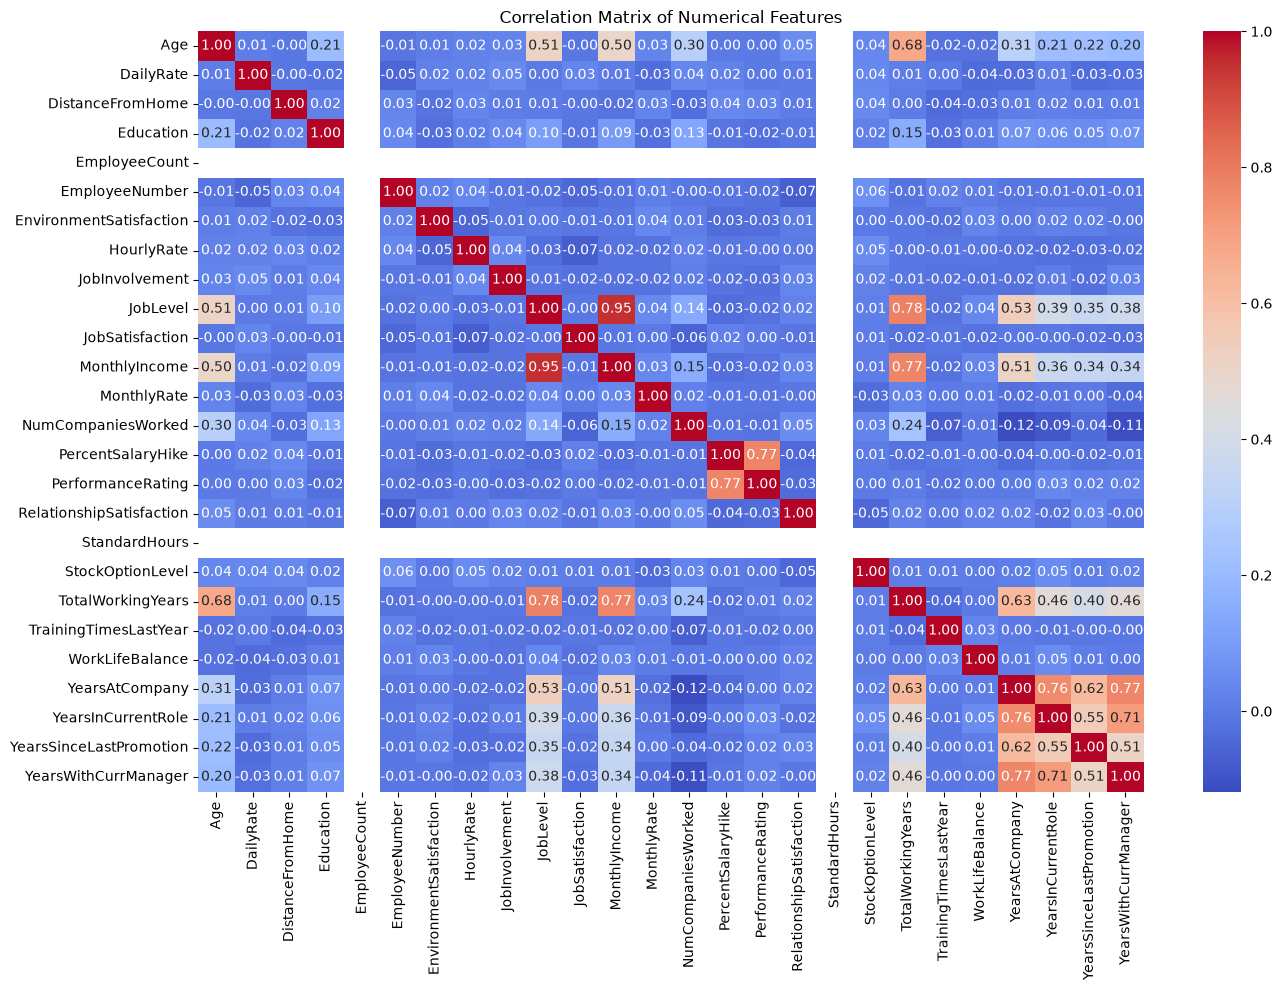

In [31]:
correlation_matrix = df[numerical_columns].corr()

correlation_matrix


plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Observation

The correlation matrix is examined to identify numerical variables with
strong relationships.

Strongly correlated variables may contain overlapping information, but they
are not removed automatically.

The correlation results will be considered together with the meaning of the
variables and later model performance.

Only meaningful feature transformations will be created.

In [32]:
for column in categorical_columns:

    print("\n" + "=" * 50)
    print(column)
    print("=" * 50)

    print(
        df[column].value_counts(normalize=True).mul(100).round(2)
    )


Attrition
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

BusinessTravel
BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64

Department
Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64

EducationField
EducationField
Life Sciences       41.22
Medical             31.56
Marketing           10.82
Technical Degree     8.98
Other                5.58
Human Resources      1.84
Name: proportion, dtype: float64

Gender
Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64

JobRole
JobRole
Sales Executive              22.18
Research Scientist           19.86
Laboratory Technician        17.62
Manufacturing Director        9.86
Healthcare Representative     8.91
Manager                       6.94
Sales Representative          5.65
Research Director             5.44
Human Resources             

## Near-Constant Categorical Feature Investigation

Categorical features are checked to determine whether one category dominates
almost all observations.

A highly dominant category does not automatically make a feature useless,
so the feature will only be considered for removal if the distribution shows
that it provides insufficient information.

This investigation helps avoid unnecessary feature engineering and feature
selection decisions.

In [33]:
df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 20, float("inf")],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "11-20 Years",
        "20+ Years"
    ]
)

print(df["TenureGroup"].value_counts().sort_index())

TenureGroup
0-2 Years      342
3-5 Years      434
6-10 Years     448
11-20 Years    180
20+ Years       66
Name: count, dtype: int64


### Investigation of Tenure Groups

The number of employees in each tenure group is examined.

This check is necessary because a category containing very few observations
may not provide reliable information.

If the groups have reasonable representation, their relationship with
Attrition will be examined before deciding whether TenureGroup should be
retained.

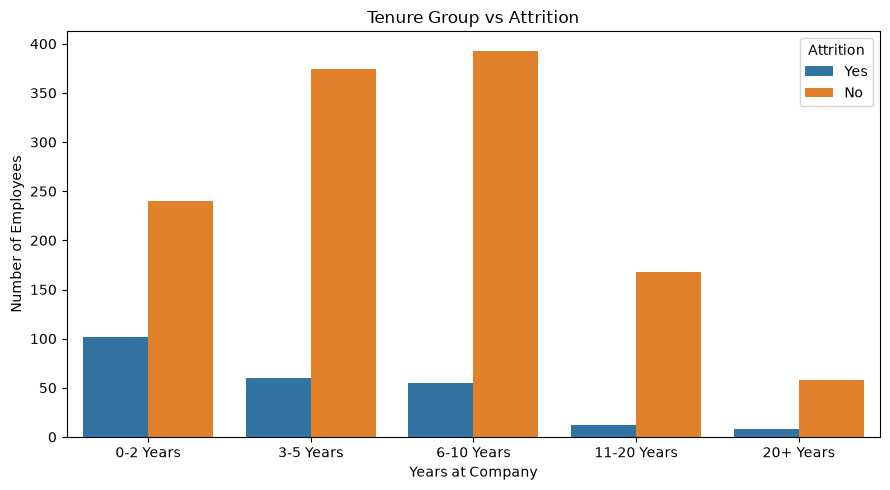

In [34]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Attrition"
)

plt.title("Tenure Group vs Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

### Decision

The distribution of Attrition across the tenure groups is examined.

If TenureGroup shows a clearer and meaningful pattern with Attrition, it may
be retained as an additional engineered feature.

If it does not provide useful additional information, the original
YearsAtCompany variable will be preferred because it preserves more precise
information.

Therefore, the engineered feature is evaluated rather than automatically
accepted.

In [35]:
df["CurrentRoleTenureRatio"] = (
    df["YearsInCurrentRole"] /
    (df["YearsAtCompany"] + 1)
)

print(df[
    [
        "YearsAtCompany",
        "YearsInCurrentRole",
        "CurrentRoleTenureRatio"
    ]
].head(10))

   YearsAtCompany  YearsInCurrentRole  CurrentRoleTenureRatio
0               6                   4                0.571429
1              10                   7                0.636364
2               0                   0                0.000000
3               8                   7                0.777778
4               2                   2                0.666667
5               7                   7                0.875000
6               1                   0                0.000000
7               1                   0                0.000000
8               9                   7                0.700000
9               7                   7                0.875000


##  Role Tenure Ratio

YearsAtCompany represents the total number of years an employee has spent
with the company, while YearsInCurrentRole represents the number of years
spent in the current role.

A ratio between these variables can provide an additional representation of
how much of an employee's company tenure has been spent in the current role.

This feature is investigated because employees who have remained in the same
role for a large proportion of their company tenure may have a different
attrition pattern.

The original variables are retained because they contain independent
information that may be lost by replacing them with a ratio.

In [36]:
print(df["CurrentRoleTenureRatio"].describe())

count    1470.000000
mean        0.480701
std         0.274128
min         0.000000
25%         0.333333
50%         0.500000
75%         0.666667
max         0.882353
Name: CurrentRoleTenureRatio, dtype: float64


##

The descriptive statistics of the newly created feature are examined to
identify its range, central tendency, and possible extreme values.

The feature will not automatically be retained. Its relationship with
Attrition and its usefulness compared with the original variables will be
evaluated later.

In [37]:
department_jobrole = (
    df.groupby(["Department", "JobRole"])
    .size()
    .reset_index(name="EmployeeCount")
)

department_jobrole

,Department,JobRole,EmployeeCount
0,Human Resources,Human Resources,52
1,Human Resources,Manager,11
2,Research & Development,Healthcare Representative,131
3,Research & Development,Laboratory Technician,259
4,Research & Development,Manager,54
5,Research & Development,Manufacturing Director,145
6,Research & Development,Research Director,80
7,Research & Development,Research Scientist,292
8,Sales,Manager,37
9,Sales,Sales Executive,326


### 

The Department–JobRole combinations are examined to determine whether the
combination provides meaningful and sufficiently represented groups.

Very rare combinations may not be suitable for creating a new categorical
feature because they can provide unreliable information.

Therefore, the combination will only be considered for feature engineering
if the resulting categories are meaningful and adequately represented.

In [38]:
department_jobrole_attrition = pd.crosstab(
    [df["Department"], df["JobRole"]],
    df["Attrition"],
    normalize="index"
) * 100

department_jobrole_attrition.round(2)

Attrition                                             No    Yes
Department             JobRole                                 
Human Resources        Human Resources             76.92  23.08
                       Manager                    100.00   0.00
Research & Development Healthcare Representative   93.13   6.87
                       Laboratory Technician       76.06  23.94
                       Manager                     94.44   5.56
                       Manufacturing Director      93.10   6.90
                       Research Director           97.50   2.50
                       Research Scientist          83.90  16.10
Sales                  Manager                     94.59   5.41
                       Sales Executive             82.52  17.48
                       Sales Representative        60.24  39.76



The percentage of employees who stayed and left is compared across
Department–JobRole combinations.

Large differences may indicate that the combination contains useful
information for Attrition prediction.

However, combinations with very few employees should not be interpreted
strongly because their percentages may be unstable.

The results will be considered before deciding whether to create a combined
categorical feature.

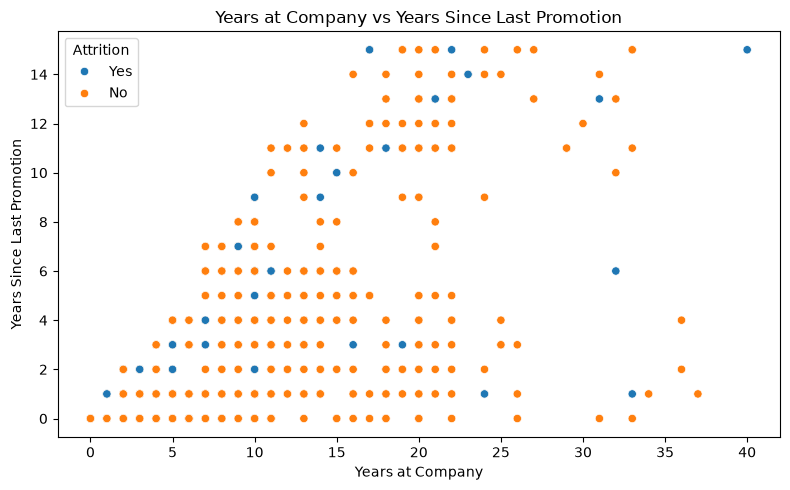

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="YearsAtCompany",
    y="YearsSinceLastPromotion",
    hue="Attrition"
)

plt.title("Years at Company vs Years Since Last Promotion")
plt.xlabel("Years at Company")
plt.ylabel("Years Since Last Promotion")

plt.tight_layout()
plt.show()

##

The relationship between total company tenure and time since the last
promotion is examined.

The distribution is compared across Attrition classes to determine whether
career progression may contain useful information.

A derived feature will only be created if the relationship provides a
meaningful representation that is not already captured sufficiently by the
original variables.

In [40]:
df["PromotionGapRatio"] = (
    df["YearsSinceLastPromotion"] /
    (df["YearsAtCompany"] + 1)
)

print(df[
    [
        "YearsAtCompany",
        "YearsSinceLastPromotion",
        "PromotionGapRatio"
    ]
].head(10))

   YearsAtCompany  YearsSinceLastPromotion  PromotionGapRatio
0               6                        0           0.000000
1              10                        1           0.090909
2               0                        0           0.000000
3               8                        3           0.333333
4               2                        2           0.666667
5               7                        3           0.375000
6               1                        0           0.000000
7               1                        0           0.000000
8               9                        1           0.100000
9               7                        7           0.875000


###

The newly created PromotionGapRatio is inspected to ensure that the
calculation was successful and that no division-by-zero problem occurred.

The feature is not automatically accepted.

Its distribution, relationship with Attrition, and usefulness compared with
the original variables will be considered during feature evaluation and
model comparison.

In [41]:
print(df["PromotionGapRatio"].describe())

count    1470.000000
mean        0.236458
std         0.269358
min         0.000000
25%         0.000000
50%         0.142857
75%         0.428571
max         0.916667
Name: PromotionGapRatio, dtype: float64


### Statistical Summary of PromotionGapRatio

The descriptive statistics of the newly created PromotionGapRatio are
examined using the describe() function.

The summary provides the count, mean, standard deviation, minimum, quartiles,
and maximum values.

This helps us understand the central tendency, spread, and range of the
engineered feature and identify whether unusually large values may require
further investigation.

The feature will not be modified or removed based only on these statistics.
Its usefulness will be evaluated further before making the final feature
selection decision.

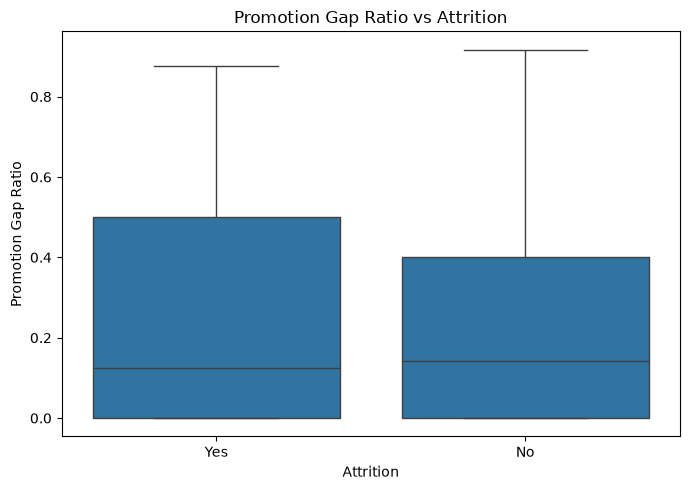

In [42]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="PromotionGapRatio"
)

plt.title("Promotion Gap Ratio vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Promotion Gap Ratio")

plt.tight_layout()
plt.show()

### 

The distribution of PromotionGapRatio is compared between employees who
stayed and employees who left.

Differences in the median and spread between the two groups are examined.

The presence of a visible difference does not by itself prove that the
feature improves the machine learning model. Therefore, the final usefulness
of PromotionGapRatio will be verified later through feature selection and
model performance comparison.

If the feature does not provide additional useful information, it will not
be retained in the final model.

In [43]:
engineered_features = [
    "CurrentRoleTenureRatio",
    "PromotionGapRatio"
]

for feature in engineered_features:

    print("\n" + "=" * 50)
    print(feature)
    print("=" * 50)

    print(
        df.groupby("Attrition")[feature]
        .median()
    )


CurrentRoleTenureRatio
Attrition
No     0.529412
Yes    0.428571
Name: CurrentRoleTenureRatio, dtype: float64

PromotionGapRatio
Attrition
No     0.142857
Yes    0.125000
Name: PromotionGapRatio, dtype: float64


## Statistical Comparison of Engineered Features

Visual inspection alone is not sufficient to decide whether an engineered
feature is useful.

Therefore, the numerical engineered features are compared between the two
Attrition groups using their median values.

The median is preferred for this investigation because it is less affected
by extreme observations than the mean.

This comparison helps identify whether the engineered features show a
noticeable difference between employees who stayed and employees who left.

The result is used as supporting evidence, not as the only criterion for
final feature selection.

In [44]:
for feature in engineered_features:

    print("\n" + "=" * 50)
    print(feature)
    print("=" * 50)

    comparison = df.groupby("Attrition")[feature].agg(
        ["mean", "median"]
    )

    print(comparison)


CurrentRoleTenureRatio
               mean    median
Attrition                    
No         0.499639  0.529412
Yes        0.382178  0.428571

PromotionGapRatio
               mean    median
Attrition                    
No         0.235228  0.142857
Yes        0.242853  0.125000


### 

The mean and median values are compared for employees who stayed and
employees who left.

The difference between the two statistics is examined to determine whether
the engineered feature is strongly influenced by extreme observations.

A difference between the Attrition groups may indicate that the feature
contains useful information, but this alone does not guarantee improved
model performance.

The final decision will be made after feature selection and model
evaluation.

In [45]:


features_to_compare = [
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "CurrentRoleTenureRatio",
    "PromotionGapRatio"
]

comparison = df.groupby("Attrition")[features_to_compare].median()

comparison

,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,CurrentRoleTenureRatio,PromotionGapRatio
Attrition,,,,,
No,6.0,3.0,1.0,0.529412,0.142857
Yes,3.0,2.0,1.0,0.428571,0.125000


### 

The median values of the original and engineered features are compared
between employees who stayed and employees who left.

The engineered features are considered useful only when they provide a
meaningful representation that is not already adequately captured by the
original variables.

The comparison is treated as supporting evidence rather than a final
selection criterion.

The final decision will be validated during feature selection and model
comparison.

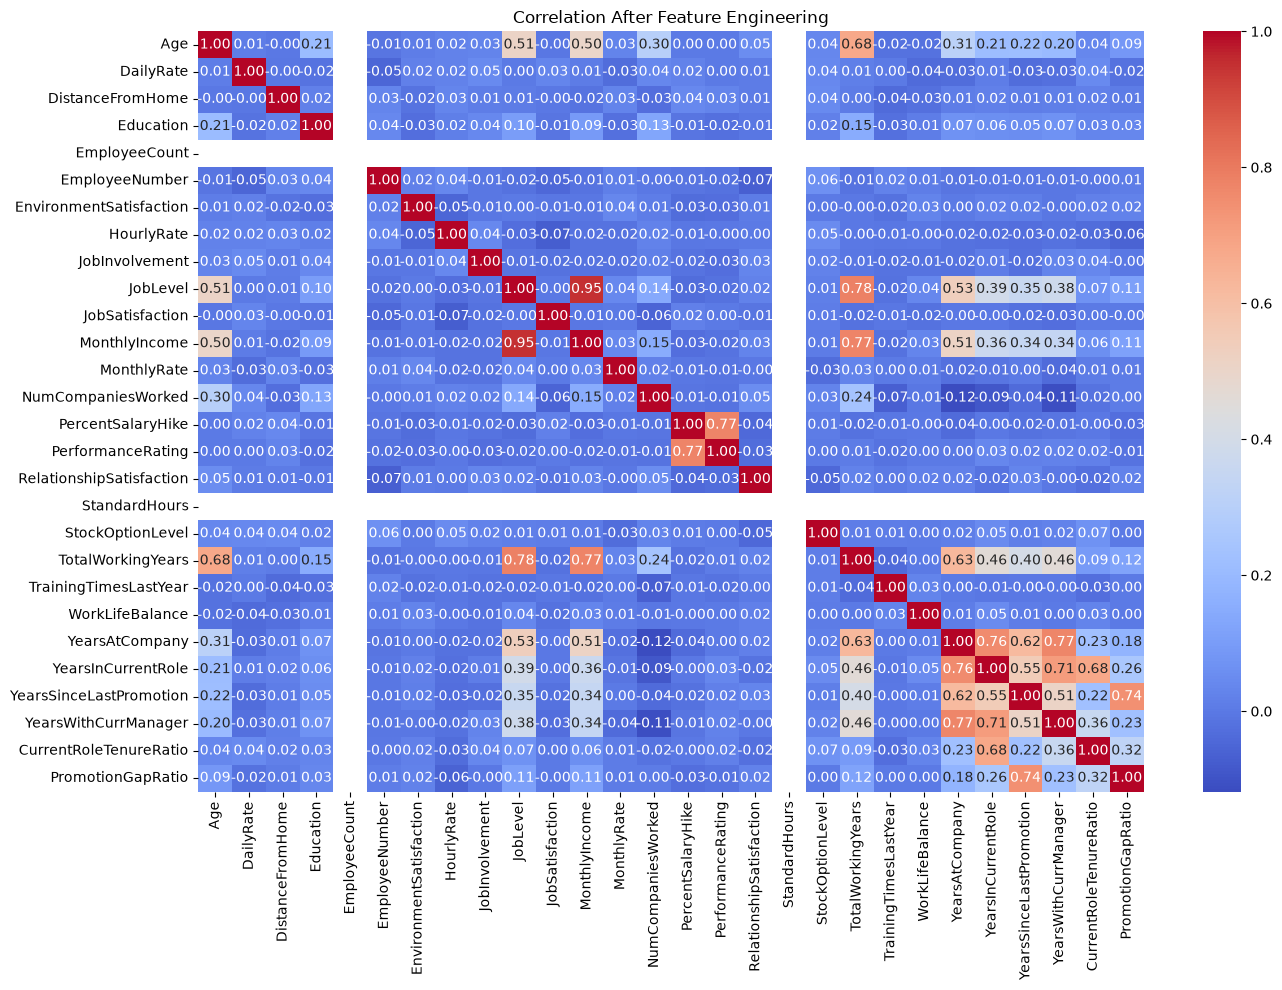

In [46]:

engineered_correlation = df[
    list(numerical_columns) +
    [
        "CurrentRoleTenureRatio",
        "PromotionGapRatio"
    ]
].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    engineered_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation After Feature Engineering")
plt.tight_layout()
plt.show()

### 

The correlation matrix after feature engineering is examined to determine
whether the newly created features have strong relationships with the
existing numerical variables.

Highly correlated features may contain overlapping information. However,
correlation alone is not used to remove a feature.

The meaning of the feature, its relationship with Attrition, and its
contribution to model performance will also be considered before making the
final feature-selection decision.

In [47]:
new_features = [
    "CurrentRoleTenureRatio",
    "PromotionGapRatio"
]

print(
    engineered_correlation.loc[
        new_features,
        list(numerical_columns)
    ].round(2)
)

                         Age  DailyRate  DistanceFromHome  Education  \
CurrentRoleTenureRatio  0.04       0.04              0.02       0.03   
PromotionGapRatio       0.09      -0.02              0.01       0.03   

                        EmployeeCount  EmployeeNumber  \
CurrentRoleTenureRatio            NaN           -0.00   
PromotionGapRatio                 NaN            0.01   

                        EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
CurrentRoleTenureRatio                     0.02       -0.03            0.04   
PromotionGapRatio                          0.02       -0.06           -0.00   

                        JobLevel  JobSatisfaction  MonthlyIncome  MonthlyRate  \
CurrentRoleTenureRatio      0.07              0.0           0.06         0.01   
PromotionGapRatio           0.11             -0.0           0.11         0.01   

                        NumCompaniesWorked  PercentSalaryHike  \
CurrentRoleTenureRatio               -0.02              -0.00   

###

The correlations of the newly engineered features with the original
numerical variables are examined separately.

This focused comparison makes it easier to determine whether the engineered
features provide information that is substantially different from the
existing variables.

A strong correlation with an original variable does not automatically mean
that the engineered feature must be removed. The final decision will also
consider its interpretation, relationship with Attrition, and model
performance.

# FEATURE SELECTION

Feature selection is performed to identify the most useful variables for
predicting employee Attrition.



In [48]:


constant_columns = [
    column for column in df.columns
    if df[column].nunique() == 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['EmployeeCount', 'Over18', 'StandardHours']


### 

A constant feature contains the same value for every observation.

Such a feature cannot help the model distinguish between employees with
different Attrition outcomes.

Therefore, constant features are removed from the dataset.

This is preferred over keeping them because they provide no predictive
information and only increase the number of variables.

In [49]:
df = df.drop(columns=constant_columns)

print("Shape after removing constant features:", df.shape)

Shape after removing constant features: (1470, 35)


### 

The constant features identified during the investigation were removed.

These variables were removed because they contain only one unique value and
therefore cannot contribute to distinguishing the Attrition classes.

Removing them reduces unnecessary variables without removing useful
information from the dataset.

In [50]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

if "Attrition" in numerical_features:
    numerical_features.remove("Attrition")

print("Number of numerical features:", len(numerical_features))
print("\nNumerical features:")
print(numerical_features)

Number of numerical features: 26

Numerical features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'CurrentRoleTenureRatio', 'PromotionGapRatio']


##

The numerical features remaining after removing the constant variables are
listed.

These variables will be compared between the two Attrition classes using
their descriptive statistics and appropriate statistical tests.

The purpose is to identify whether there is evidence that the distributions
of numerical variables differ between employees who stayed and employees
who left.

In [51]:
median_comparison = df.groupby("Attrition")[numerical_features].median().T

median_comparison

Attrition,No,Yes
Age,36.000000,32.000000
DailyRate,817.000000,699.000000
DistanceFromHome,7.000000,9.000000
Education,3.000000,3.000000
EmployeeNumber,1022.000000,1017.000000
EnvironmentSatisfaction,3.000000,3.000000
HourlyRate,66.000000,66.000000
JobInvolvement,3.000000,3.000000
JobLevel,2.000000,1.000000
JobSatisfaction,3.000000,3.000000


### 

The median of each numerical feature is compared between employees who stayed
and employees who left.

Features showing noticeable differences in their median values may have a
potential relationship with Attrition.

However, median comparison alone cannot determine statistical significance.
Therefore, statistical tests will be used as the next step to investigate
whether the observed differences are statistically meaningful.

In [52]:
from scipy.stats import mannwhitneyu

# Separate the two Attrition groups
attrition_yes = df[df["Attrition"] == "Yes"]
attrition_no = df[df["Attrition"] == "No"]

results = []

for feature in numerical_features:

    yes_values = attrition_yes[feature].dropna()
    no_values = attrition_no[feature].dropna()

    statistic, p_value = mannwhitneyu(
        yes_values,
        no_values,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": statistic,
        "P-Value": p_value
    })

mannwhitney_results = pd.DataFrame(results)

mannwhitney_results = mannwhitney_results.sort_values(
    "P-Value"
)

mannwhitney_results

,Feature,U Statistic,P-Value
17,TotalWorkingYears,100567.0,2.399569e-14
10,MonthlyIncome,100620.5,2.950831e-14
20,YearsAtCompany,102582.0,2.916191e-13
8,JobLevel,104729.5,2.956987e-13
21,YearsInCurrentRole,105214.0,4.429560e-12
23,YearsWithCurrManager,106361.5,1.806754e-11
16,StockOptionLevel,109611.0,4.013375e-11
0,Age,106859.0,5.304342e-11
24,CurrentRoleTenureRatio,113631.0,4.914993e-08
7,JobInvolvement,121957.0,4.651927e-06


In [53]:
mannwhitney_results["Significant"] = np.where(
    mannwhitney_results["P-Value"] < 0.05,
    "Yes",
    "No"
)

mannwhitney_results

,Feature,U Statistic,P-Value,Significant
17,TotalWorkingYears,100567.0,2.399569e-14,Yes
10,MonthlyIncome,100620.5,2.950831e-14,Yes
20,YearsAtCompany,102582.0,2.916191e-13,Yes
8,JobLevel,104729.5,2.956987e-13,Yes
21,YearsInCurrentRole,105214.0,4.429560e-12,Yes
23,YearsWithCurrManager,106361.5,1.806754e-11,Yes
16,StockOptionLevel,109611.0,4.013375e-11,Yes
0,Age,106859.0,5.304342e-11,Yes
24,CurrentRoleTenureRatio,113631.0,4.914993e-08,Yes
7,JobInvolvement,121957.0,4.651927e-06,Yes


### Statistical Testing of Numerical Features

The Mann–Whitney U test is applied to compare each numerical feature between
employees who left the company and employees who stayed.

This non-parametric test is selected because it does not require the numerical
variables to follow a normal distribution and is suitable for comparing two
independent groups.

The null hypothesis states that there is no significant difference in the
distribution of the feature between the two Attrition groups.

A p-value less than 0.05 is considered statistically significant.

The statistical test is used as supporting evidence for feature selection and
not as the only criterion for deciding whether a feature should be retained.

The p-value for each numerical feature is examined.

If p-value < 0.05, the difference between the two Attrition groups is
considered statistically significant.

If p-value >= 0.05, there is insufficient statistical evidence to conclude
that the feature differs significantly between the two Attrition groups.

Statistical significance does not necessarily mean that a feature will
improve model performance. Therefore, these results will be combined with
correlation, feature importance, and model evaluation during the final
feature-selection process.

In [54]:
from scipy.stats import chi2_contingency

categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Remove target variable
if "Attrition" in categorical_features:
    categorical_features.remove("Attrition")

chi_square_results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["Attrition"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_square_results.append({
        "Feature": feature,
        "Chi2 Statistic": chi2,
        "P-Value": p_value
    })

chi_square_results = pd.DataFrame(chi_square_results)

chi_square_results = chi_square_results.sort_values(
    "P-Value"
)

chi_square_results

C:\Users\lksch\AppData\Local\Temp\ipykernel_12584\3268578765.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


,Feature,Chi2 Statistic,P-Value
6,OverTime,87.564294,8.158424e-21
4,JobRole,86.190254,2.752482e-15
7,TenureGroup,66.757609,1.096630e-13
5,MaritalStatus,46.163677,9.455511e-11
0,BusinessTravel,24.182414,5.608614e-06
1,Department,10.796007,4.525607e-03
2,EducationField,16.024674,6.773980e-03
3,Gender,1.116967,2.905724e-01


In [55]:
chi_square_results["Significant"] = np.where(
    chi_square_results["P-Value"] < 0.05,
    "Yes",
    "No"
)

chi_square_results

,Feature,Chi2 Statistic,P-Value,Significant
6,OverTime,87.564294,8.158424e-21,Yes
4,JobRole,86.190254,2.752482e-15,Yes
7,TenureGroup,66.757609,1.096630e-13,Yes
5,MaritalStatus,46.163677,9.455511e-11,Yes
0,BusinessTravel,24.182414,5.608614e-06,Yes
1,Department,10.796007,4.525607e-03,Yes
2,EducationField,16.024674,6.773980e-03,Yes
3,Gender,1.116967,2.905724e-01,No


###

The p-value of each categorical feature is examined.

If p-value < 0.05, there is statistically significant evidence of an
association between the categorical feature and Attrition.

If p-value >= 0.05, there is insufficient statistical evidence to conclude
that the feature is associated with Attrition.

The results are used together with the earlier EDA, feature engineering,
correlation analysis, and later model performance to make the final feature
selection decision.

In [56]:
numerical_results = mannwhitney_results[
    ["Feature", "P-Value"]
].copy()

numerical_results["Test"] = "Mann-Whitney U"



categorical_results = chi_square_results[
    ["Feature", "P-Value"]
].copy()

categorical_results["Test"] = "Chi-Square"


statistical_results = pd.concat(
    [numerical_results, categorical_results],
    ignore_index=True
)

statistical_results = statistical_results.sort_values(
    "P-Value"
).reset_index(drop=True)

statistical_results["Significant"] = np.where(
    statistical_results["P-Value"] < 0.05,
    "Yes",
    "No"
)

statistical_results

,Feature,P-Value,Test,Significant
0,OverTime,8.158424e-21,Chi-Square,Yes
1,JobRole,2.752482e-15,Chi-Square,Yes
2,TotalWorkingYears,2.399569e-14,Mann-Whitney U,Yes
3,MonthlyIncome,2.950831e-14,Mann-Whitney U,Yes
4,TenureGroup,1.096630e-13,Chi-Square,Yes
5,YearsAtCompany,2.916191e-13,Mann-Whitney U,Yes
6,JobLevel,2.956987e-13,Mann-Whitney U,Yes
7,YearsInCurrentRole,4.429560e-12,Mann-Whitney U,Yes
8,YearsWithCurrManager,1.806754e-11,Mann-Whitney U,Yes
9,StockOptionLevel,4.013375e-11,Mann-Whitney U,Yes


### 

The combined statistical results provide an overall view of the relationship
between the predictor variables and Attrition.

Features with p-values below 0.05 show statistically significant evidence of
a relationship with Attrition.

Features with p-values greater than or equal to 0.05 do not show sufficient
statistical evidence of a relationship at the 5% significance level.

These results are used to identify candidate features for further
investigation rather than immediately removing all non-significant features.

In [57]:
significant_features = statistical_results[
    statistical_results["P-Value"] < 0.05
]

print("Statistically significant features:")
print(significant_features)

Statistically significant features:
                    Feature       P-Value            Test Significant
0                  OverTime  8.158424e-21      Chi-Square         Yes
1                   JobRole  2.752482e-15      Chi-Square         Yes
2         TotalWorkingYears  2.399569e-14  Mann-Whitney U         Yes
3             MonthlyIncome  2.950831e-14  Mann-Whitney U         Yes
4               TenureGroup  1.096630e-13      Chi-Square         Yes
5            YearsAtCompany  2.916191e-13  Mann-Whitney U         Yes
6                  JobLevel  2.956987e-13  Mann-Whitney U         Yes
7        YearsInCurrentRole  4.429560e-12  Mann-Whitney U         Yes
8      YearsWithCurrManager  1.806754e-11  Mann-Whitney U         Yes
9          StockOptionLevel  4.013375e-11  Mann-Whitney U         Yes
10                      Age  5.304342e-11  Mann-Whitney U         Yes
11            MaritalStatus  9.455511e-11      Chi-Square         Yes
12   CurrentRoleTenureRatio  4.914993e-08  Mann-Whitne

### 

The statistically significant features are identified as candidate
predictors.

These features show evidence of an association with Attrition at the 5%
significance level.

They will be considered along with correlation, redundancy, practical
interpretation, and model performance before the final feature set is
selected.

In [58]:


correlation_matrix = df[numerical_features].corr()


high_correlation_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        correlation_value = correlation_matrix.iloc[i, j]

        if abs(correlation_value) >= 0.80:
            high_correlation_pairs.append({
                "Feature 1": correlation_matrix.columns[i],
                "Feature 2": correlation_matrix.columns[j],
                "Correlation": round(correlation_value, 3)
            })

high_correlation_pairs = pd.DataFrame(high_correlation_pairs)

high_correlation_pairs

,Feature 1,Feature 2,Correlation
0,JobLevel,MonthlyIncome,0.95


### 

Pairs of numerical features with an absolute correlation of 0.80 or higher
are identified as highly correlated.

These pairs are investigated for possible redundancy.

If no highly correlated pairs are found, there is no strong evidence of
multicollinearity based on the selected threshold.

If highly correlated pairs are found, the features will be compared based on
their interpretation, statistical relationship with Attrition, and model
importance before deciding whether one should be removed.

In [59]:

df = df.drop(columns=["MonthlyIncome"])

print("Removed feature: MonthlyIncome")
print("Remaining number of features:", df.shape[1])

Removed feature: MonthlyIncome
Remaining number of features: 34


### 

Highly correlated features may contain similar information and can introduce multicollinearity into the dataset.

The correlation analysis identified a strong correlation between JobLevel and MonthlyIncome with a correlation coefficient of 0.95.

Since these two variables provide highly similar information, one of them can be removed to reduce redundancy.

In this project, JobLevel is retained because it represents the employee's position level, while MonthlyIncome is removed to reduce multicollinearity.

#### DATA PREPROCESSING



In [60]:
# Convert Attrition into binary form
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print(df["Attrition"].unique())

[1 0]


###

Machine learning algorithms require numerical input, while the dataset contains several categorical variables.

Categorical features are converted into numerical representation using one-hot encoding.

One-hot encoding creates separate binary columns for the categories of each categorical variable. This allows the machine learning models to use categorical information without assuming any numerical order between categories.

The target variable Attrition is also converted into binary form, where Yes represents employee attrition and No represents no attrition.

In [61]:

categorical_columns = df.drop(columns=["Attrition"]).select_dtypes(
    include="object"
).columns


df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)


bool_columns = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

print("Dataset shape after encoding:", df_encoded.shape)
df_encoded.head()

Dataset shape after encoding: (1470, 48)


C:\Users\lksch\AppData\Local\Temp\ipykernel_12584\3852467093.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.drop(columns=["Attrition"]).select_dtypes(


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureGroup,CurrentRoleTenureRatio,PromotionGapRatio,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,4,19479,8,11,3,1,0,8,0,1,6,4,0,5,6-10 Years,0.571429,0.000000,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,2,3,61,2,2,2,24907,1,23,4,4,1,10,3,3,10,7,1,7,6-10 Years,0.636364,0.090909,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,4,92,2,1,3,2396,6,15,3,2,0,7,3,3,0,0,0,0,0-2 Years,0.000000,0.000000,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,5,4,56,3,1,3,23159,1,11,3,3,0,8,3,3,8,7,3,0,6-10 Years,0.777778,0.333333,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,7,1,40,3,1,2,16632,9,12,3,4,1,6,3,3,2,2,2,2,0-2 Years,0.666667,0.666667,0,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0



### Categorical Feature Encoding

The dataset contains categorical variables with text-based values.

Machine learning algorithms require numerical input, so categorical variables need to be converted into numerical form.

One-hot encoding is used to convert the categorical variables into binary numerical columns. This represents each category without assigning an artificial numerical order.

The target variable Attrition is also converted into binary form, where Yes represents employee attrition and No represents no attrition.

This prepares the categorical data for the subsequent machine learning preprocessing steps.

In [62]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (1176, 47)
Testing data shape: (294, 47)
Training target shape: (1176,)
Testing target shape: (294,)


## Train-Test Split

The encoded dataset is divided into training and testing subsets.

The training dataset is used to train the machine learning models, while the testing dataset is reserved for evaluating model performance on unseen data.

An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

Stratified splitting is applied to maintain the proportion of the target classes in both training and testing datasets.

In [63]:
print("Attrition class distribution:")
print(y_train.value_counts())

print("\nAttrition class percentage:")
print(y_train.value_counts(normalize=True) * 100)

Attrition class distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Attrition class percentage:
Attrition
0    83.843537
1    16.156463
Name: proportion, dtype: float64


### Class Imbalance Check

Class imbalance occurs when the target classes are not represented equally in the dataset.

In this project, the target variable Attrition contains two classes:
 0 – Employee did not leave the company
 1 – Employee left the company

The distribution of the target classes in the training data is examined before deciding whether a balancing technique is required.

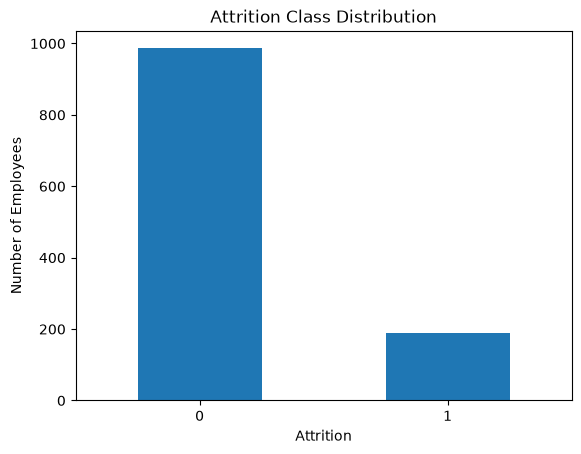

In [64]:
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind="bar")

plt.title("Attrition Class Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

###  

The target variable shows an unequal distribution between employees who stayed and employees who left the organization.

Class imbalance can cause a machine learning model to favor the majority class and perform poorly when predicting the minority class.

To address this issue, Random Over-Sampling is applied to the training data. The minority class is increased by randomly sampling existing minority-class observations.

Only the training data is balanced, while the testing data remains unchanged to provide an unbiased evaluation of model performance.

In [65]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
from imblearn.over_sampling import RandomOverSampler


In [67]:
ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train,
    y_train
)

print("Before balancing:")
print(y_train.value_counts())

print("\nAfter balancing:")
print(y_train_balanced.value_counts())

Before balancing:
Attrition
0    986
1    190
Name: count, dtype: int64

After balancing:
Attrition
0    986
1    986
Name: count, dtype: int64


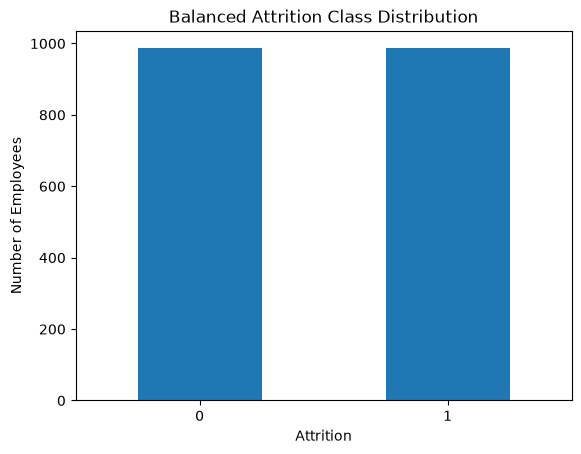

In [68]:
y_train_balanced.value_counts().plot(kind="bar")

plt.title("Balanced Attrition Class Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

###  Result After Balancing

Random over-sampling was successfully applied to the training dataset.

The minority class was increased by randomly duplicating existing samples so that both Attrition classes have an equal number of observations.

The class distribution after balancing is now approximately equal between:
0 – No Attrition
 1 – Attrition

The test dataset was not modified and remains unchanged for unbiased model evaluation.

The balanced training dataset is now ready for the next preprocessing step: feature scaling.

In [69]:



tenure_mapping = {
    "0-2 Years": 0,
    "3-5 Years": 1,
    "6-10 Years": 2,
    "11-20 Years": 3,
    "20+ Years": 4
}

df_encoded["TenureGroup"] = df_encoded["TenureGroup"].map(tenure_mapping)

print("TenureGroup dtype:", df_encoded["TenureGroup"].dtype)

print("\nRemaining categorical columns:")
print(df_encoded.select_dtypes(include=["object", "category"]).columns.tolist())

TenureGroup dtype: category

Remaining categorical columns:
['TenureGroup']


###  Encoding the Engineered Ordinal Feature

The engineered feature TenureGroup contains ordered categories representing
different ranges of years at the company.

Since these categories have a natural progression from lower to higher
tenure, ordinal encoding is used instead of one-hot encoding.

The categories are assigned increasing numerical values while preserving
their original order.

This conversion allows the feature to be used by numerical preprocessing
methods such as standardization and machine learning algorithms.

In [97]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train, y_train
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Training data after balancing:", X_train_balanced.shape)
print("Testing data:", X_test.shape)

print("Balanced class distribution:")
print(y_train_balanced.value_counts())

print("\nScaling completed successfully.")

Training data after balancing: (1972, 47)
Testing data: (294, 47)
Balanced class distribution:
Attrition
0    986
1    986
Name: count, dtype: int64

Scaling completed successfully.


### Feature Scaling / Standardization

After categorical encoding and class balancing, feature scaling is performed
to bring numerical features to a comparable scale.

Standardization is performed using StandardScaler, which transforms the
features to have a mean of approximately 0 and a standard deviation of 1.

The scaler is fitted only on the balanced training data and then used to
transform the test data. This prevents information from the test set from
being used during preprocessing and avoids data leakage.

Scaling is especially useful for models such as Logistic Regression, SVM,
KNN, and Neural Networks, where differences in feature magnitude can affect
model performance.

# MODEL TRAINING

###  Model Selection
After completing data preprocessing, including categorical encoding, class
balancing, and feature scaling, the prepared training data is ready for
machine learning model development.

Five classification algorithms are selected for predicting employee
attrition:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. Naive Bayes

These models are trained and evaluated using Accuracy, Precision, Recall,
F1-Score, and Confusion Matrix.

The performance of the five models will be compared to identify the most
suitable model for employee attrition prediction.

In [71]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train_balanced)
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Logistic Regression

Logistic Regression is used as the first baseline classification model for
predicting employee Attrition.

It is a suitable starting model because the target variable is binary, with
0 representing employees who stayed and 1 representing employees who left.

Logistic Regression estimates the probability of an employee leaving the
organization based on the input features.

The model is trained using the balanced and standardized training data.
Its performance will be evaluated on the original, untouched test data.

Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix will be used
to evaluate the model.

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------
Accuracy  : 0.7653
Precision : 0.3750
Recall    : 0.7021
F1-Score  : 0.4889

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       247
           1       0.38      0.70      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.79       294



###  Logistic Regression Evaluation

The trained Logistic Regression model is evaluated using the predictions
generated on the unseen test dataset.

Accuracy, Precision, Recall, and F1-Score are calculated to measure the
classification performance.

The Confusion Matrix is also examined to understand the number of correctly
and incorrectly classified employees in each Attrition class.

Since employee Attrition is an imbalanced classification problem, F1-Score
and Recall are given particular attention along with Accuracy.

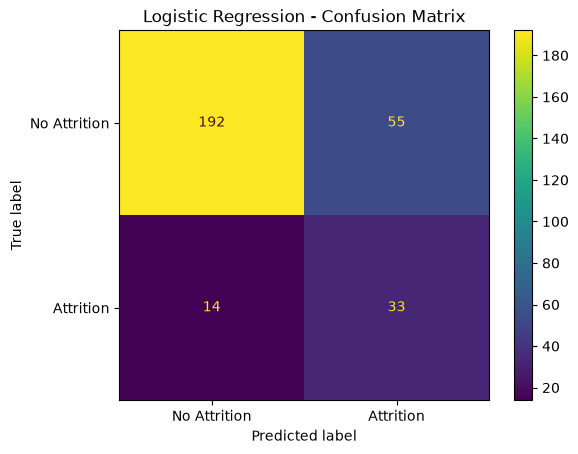

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

###  Logistic Regression — Confusion Matrix

A confusion matrix is used to examine the detailed classification results of
the Logistic Regression model.

It shows the number of true positives, true negatives, false positives, and
false negatives.

This helps us understand how well the model distinguishes between employees
who stay and employees who leave.

In [74]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)
decision_tree_model.fit(
    X_train_balanced,
    y_train_balanced
)

y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


###  Decision Tree

A Decision Tree classifier is trained as the second machine learning model
for predicting employee Attrition.

Unlike Logistic Regression, which learns a linear relationship between the
features and the target, a Decision Tree can learn non-linear relationships
by dividing the data into a series of decision rules.

The model is trained using the balanced training data. The test data remains
untouched and is used only for evaluating the model.

The Decision Tree performance will be compared with Logistic Regression using
Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance
-------------------------
Accuracy  : 0.7551
Precision : 0.2449
Recall    : 0.2553
F1-Score  : 0.2500

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       247
           1       0.24      0.26      0.25        47

    accuracy                           0.76       294
   macro avg       0.55      0.55      0.55       294
weighted avg       0.76      0.76      0.76       294



###  Decision Tree Evaluation

The trained Decision Tree model is evaluated using the predictions generated
on the unseen test dataset.

Accuracy, Precision, Recall, and F1-Score are calculated to measure the
classification performance of the model.

The Confusion Matrix is also examined to understand how many employees were
correctly and incorrectly classified into the two Attrition classes.

The results will later be compared with the other machine learning models to
identify the best-performing model.

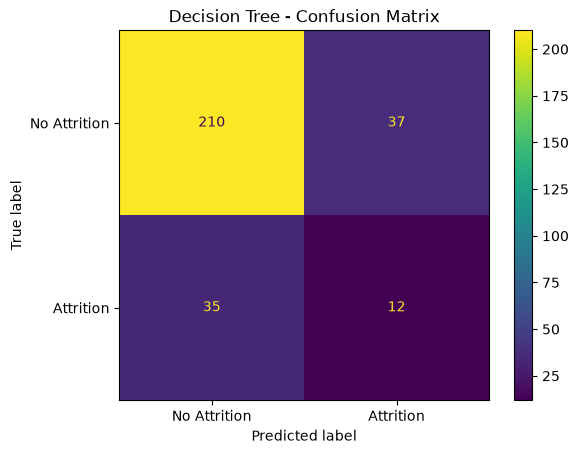

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

###  Decision Tree — Confusion Matrix

A confusion matrix is used to analyze the detailed prediction results of the
Decision Tree model.

It shows the number of correctly and incorrectly classified employees for
each Attrition class.

The confusion matrix helps identify the model's ability to distinguish
between employees who stayed and employees who left the organization.

In [77]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest_model.fit(
    X_train_balanced,
    y_train_balanced
)
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


###  Random Forest

Random Forest is used as the third machine learning model for predicting
employee Attrition.

Random Forest is an ensemble learning algorithm that combines multiple
Decision Trees to produce a more robust and accurate prediction.

Each tree learns from different samples and features, and the final
prediction is determined by combining the predictions of the individual
trees.

The model is trained using the balanced training data and evaluated on the
untouched test data.

Its performance will be compared with the previously trained Logistic
Regression and Decision Tree models using Accuracy, Precision, Recall,
F1-Score, and the Confusion Matrix.

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
------------------------
Accuracy  : 0.8333
Precision : 0.4286
Recall    : 0.1277
F1-Score  : 0.1967

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294



### Random Forest Evaluation

The trained Random Forest model is evaluated using predictions generated on
the unseen test dataset.

Accuracy, Precision, Recall, and F1-Score are calculated to measure the
classification performance of the model.

The results are used to compare Random Forest with the previously trained
Logistic Regression and Decision Tree models.

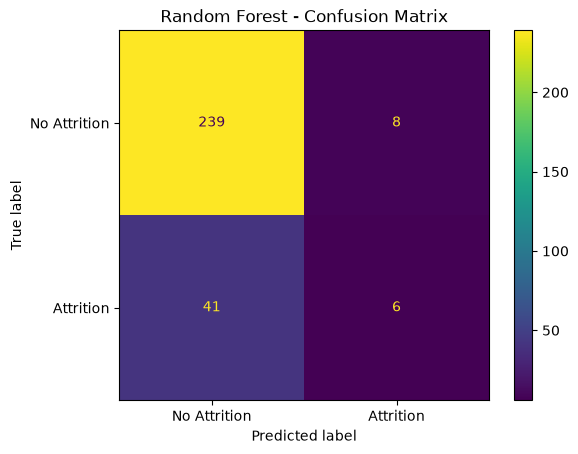

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

###  Random Forest — Confusion Matrix

A confusion matrix is used to examine the detailed classification results of
the Random Forest model.

It shows the number of true positives, true negatives, false positives, and
false negatives produced by the model.

This helps us understand how effectively Random Forest distinguishes between
employees who stayed and employees who left the organization.

In [80]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel="rbf",
    random_state=42
)
svm_model.fit(
    X_train_scaled,
    y_train_balanced
)
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM model trained successfully.")

SVM model trained successfully.


### Support Vector Machine (SVM)

Support Vector Machine (SVM) is used as the fourth machine learning model
for predicting employee Attrition.

SVM finds an optimal decision boundary that separates employees who stayed
from employees who left the organization.

The model is trained using the balanced and standardized training data.
Standardization is particularly important for SVM because the algorithm is
sensitive to the scale of input features.

The model is evaluated on the untouched test dataset using Accuracy,
Precision, Recall, F1-Score, and the Confusion Matrix.

In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Performance")
print("----------------")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Performance
----------------
Accuracy  : 0.8333
Precision : 0.4773
Recall    : 0.4468
F1-Score  : 0.4615

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       247
           1       0.48      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.69      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294



###  SVM Evaluation

The trained Support Vector Machine model is evaluated using predictions
generated on the unseen test dataset.

Accuracy, Precision, Recall, and F1-Score are calculated to measure the
classification performance of the model.

The results will be compared with the other trained classification models
to determine which model performs best for employee Attrition prediction.

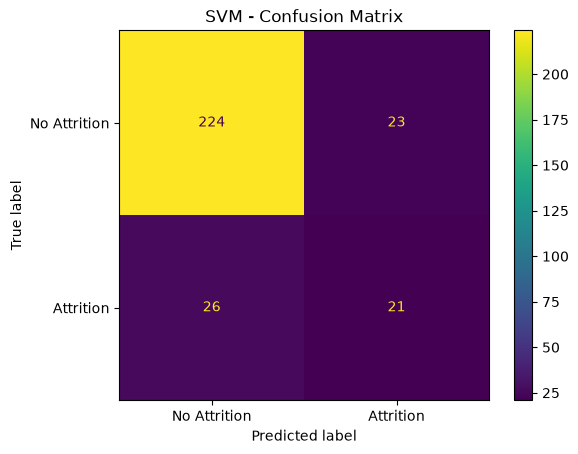

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("SVM - Confusion Matrix")
plt.show()

### SVM — Confusion Matrix

A confusion matrix is used to examine the detailed classification results
of the Support Vector Machine model.

It shows the number of correctly and incorrectly classified employees for
both Attrition classes.

The confusion matrix helps evaluate how effectively the SVM model
distinguishes between employees who stayed and employees who left.

In [83]:
from sklearn.naive_bayes import GaussianNB
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(
    X_train_scaled,
    y_train_balanced
)
y_pred_nb = naive_bayes_model.predict(X_test_scaled)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


###  Naive Bayes

Naive Bayes is used as the fifth and final machine learning model for
predicting employee Attrition.

Naive Bayes is a probabilistic classification algorithm based on Bayes'
theorem. It assumes that the input features are conditionally independent
given the target class.

The model is trained using the balanced training data and evaluated on the
untouched test dataset.

Naive Bayes performance will be evaluated using Accuracy, Precision, Recall,
F1-Score, and the Confusion Matrix and will later be compared with the other
four models.

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Performance")
print("-----------------------")
print(f"Accuracy  : {accuracy_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1-Score  : {f1_nb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Performance
-----------------------
Accuracy  : 0.5476
Precision : 0.2278
Recall    : 0.7660
F1-Score  : 0.3512

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.51      0.65       247
           1       0.23      0.77      0.35        47

    accuracy                           0.55       294
   macro avg       0.57      0.64      0.50       294
weighted avg       0.81      0.55      0.60       294



### Naive Bayes Evaluation

The trained Naive Bayes model is evaluated using predictions generated on the
unseen test dataset.

Accuracy, Precision, Recall, and F1-Score are calculated to measure the
classification performance of the model.

The results are used to compare Naive Bayes with Logistic Regression,
Decision Tree, Random Forest, and Support Vector Machine.

The model with the best overall performance will be selected for the final
employee Attrition prediction system.

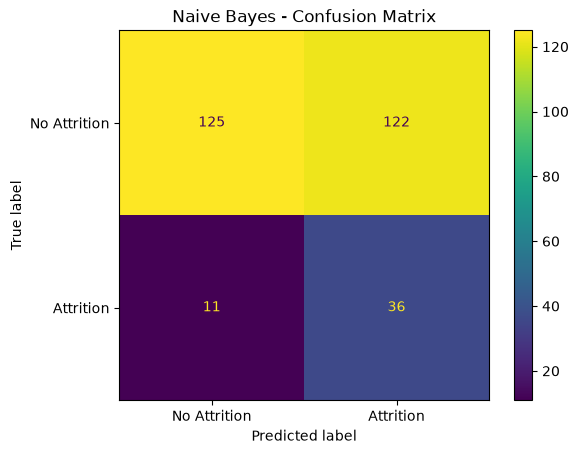

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

### Naive Bayes — Confusion Matrix

A confusion matrix is used to examine the detailed classification results of
the Naive Bayes model.

It shows the number of correctly and incorrectly classified employees for
both Attrition classes.

The confusion matrix helps evaluate how effectively the Naive Bayes model
distinguishes between employees who stayed and employees who left.

In [86]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_svm,
        accuracy_nb
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_svm,
        precision_nb
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_svm,
        recall_nb
    ],
    "F1-Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_svm,
        f1_nb
    ]
})


model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7653,0.3750,0.7021,0.4889
1,Decision Tree,0.7551,0.2449,0.2553,0.2500
2,Random Forest,0.8333,0.4286,0.1277,0.1967
3,SVM,0.8333,0.4773,0.4468,0.4615
4,Naive Bayes,0.5476,0.2278,0.7660,0.3512


#  MODEL COMPARISON

After training and evaluating all five classification models, their
performance is compared using Accuracy, Precision, Recall, and F1-Score.

A comparison of these evaluation metrics helps identify the model that
performs best for employee Attrition prediction.

F1-Score and Recall are given particular importance because correctly
identifying employees who may leave the organization is important in an
Attrition prediction system.

The model with the best overall performance will be selected for further
hyperparameter tuning and final deployment.

In [87]:
best_model_row = model_comparison.loc[
    model_comparison["F1-Score"].idxmax()
]

print("Best Model:", best_model_row["Model"])
print("Accuracy :", best_model_row["Accuracy"])
print("Precision:", best_model_row["Precision"])
print("Recall   :", best_model_row["Recall"])
print("F1-Score :", best_model_row["F1-Score"])

Best Model: Logistic Regression
Accuracy : 0.7653061224489796
Precision: 0.375
Recall   : 0.7021276595744681
F1-Score : 0.4888888888888889


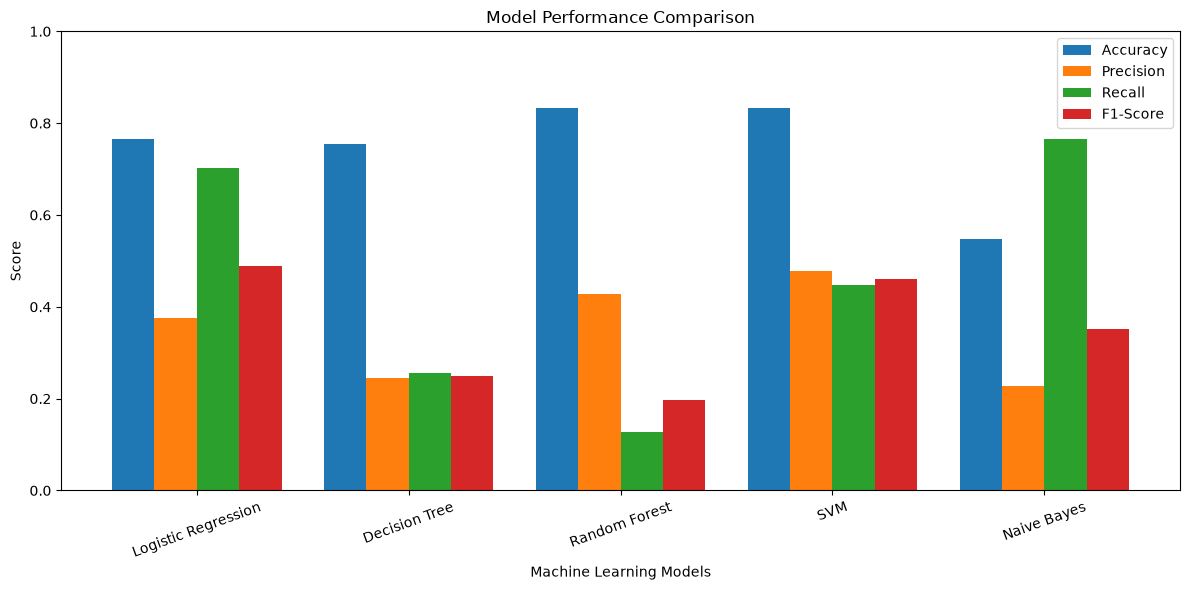

In [88]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Naive Bayes"
]
accuracy = [0.7653, 0.7551, 0.8333, 0.8333, 0.5476]
precision = [0.3750, 0.2449, 0.4286, 0.4773, 0.2278]
recall = [0.7021, 0.2553, 0.1277, 0.4468, 0.7660]
f1_score = [0.4889, 0.2500, 0.1967, 0.4615, 0.3512]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall, width, label="Recall")
plt.bar(x + 1.5*width, f1_score, width, label="F1-Score")

plt.xlabel("Machine Learning Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, models, rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

###  Best Model Selection

Based on the comparison of all five classification models, Logistic
Regression achieves the highest F1-Score of 0.4889 and a strong Recall of
0.7021.

Although Random Forest and SVM achieve higher Accuracy values of 0.8333,
their Recall values are considerably lower.

Since employee Attrition prediction requires correctly identifying employees
who may leave the organization, Recall and F1-Score are important evaluation
metrics.

Therefore, Logistic Regression is selected as the best initial model for
further tuning and final employee Attrition prediction.

In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
lr_tuning_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}
grid_search = GridSearchCV(
    estimator=lr_tuning_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train_balanced)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", round(grid_search.best_score_, 4))
best_lr_model = grid_search.best_estimator_
y_pred_best_lr = best_lr_model.predict(X_test_scaled)

print("\nTuned Logistic Regression trained successfully.")

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best Cross-Validation F1-Score: 0.7917

Tuned Logistic Regression trained successfully.


###  Hyperparameter Tuning — Logistic Regression

Hyperparameter tuning is performed to find better settings for the Logistic
Regression model.

GridSearchCV is used to test different combinations of hyperparameters and
select the combination that gives the best cross-validation F1-Score.

The regularization parameter C controls the strength of regularization,
while the solver determines the optimization algorithm used by the model.

F1-Score is selected as the scoring metric because employee Attrition is an
imbalanced classification problem and both Precision and Recall are
important.

The best-performing parameter combination is then used to train the final
Logistic Regression model.

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
accuracy_tuned = accuracy_score(y_test, y_pred_best_lr)
precision_tuned = precision_score(y_test, y_pred_best_lr)
recall_tuned = recall_score(y_test, y_pred_best_lr)
f1_tuned = f1_score(y_test, y_pred_best_lr)

print("Tuned Logistic Regression Performance")
print("-------------------------------------")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1-Score  : {f1_tuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_lr))

Tuned Logistic Regression Performance
-------------------------------------
Accuracy  : 0.7721
Precision : 0.3864
Recall    : 0.7234
F1-Score  : 0.5037

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       247
           1       0.39      0.72      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.77      0.80       294



###  Tuned Logistic Regression Evaluation

The best Logistic Regression model obtained through GridSearchCV is evaluated
on the unseen test dataset.

Accuracy, Precision, Recall, and F1-Score are calculated to determine whether
hyperparameter tuning improved the model's performance compared with the
original Logistic Regression model.

The tuned model's performance will be used for final model selection.

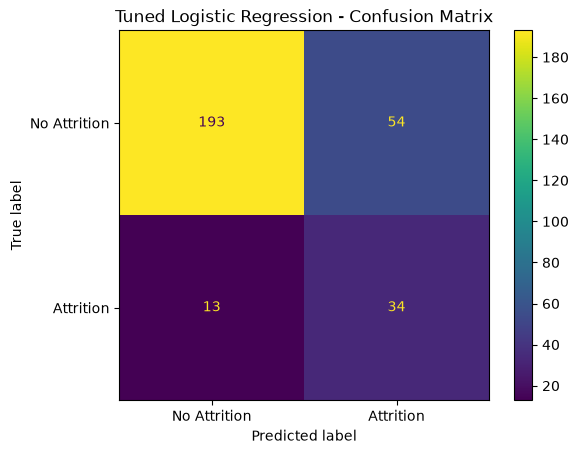

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_tuned_lr = confusion_matrix(y_test, y_pred_best_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_lr,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.show()

### Tuned Logistic Regression — Confusion Matrix

A confusion matrix is used to examine the detailed prediction results of the
tuned Logistic Regression model.

It shows the number of correctly and incorrectly classified employees for
both Attrition classes.

This helps determine how effectively the tuned model identifies employees
who stay and employees who leave.

In [92]:


tenure_mapping = {
    "0-2 Years": 0,
    "3-5 Years": 1,
    "6-10 Years": 2,
    "11-20 Years": 3,
    "20+ Years": 4
}

X["TenureGroup"] = X["TenureGroup"].map(tenure_mapping)

print("TenureGroup encoding completed.")
print(X["TenureGroup"].unique())

TenureGroup encoding completed.
[nan]


## the Decision Tree was trained earlier using a different version of your data.we are trying to tune the current/final version of your dataset, which contains TenureGroup.

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1176, 47)
X_test shape: (294, 47)


In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Decision Tree Best Parameters:", dt_grid.best_params_)
print("Decision Tree Best CV F1-Score:", round(dt_grid.best_score_, 4))

tuned_dt = dt_grid.best_estimator_

print("Tuned Decision Tree trained successfully.")

Decision Tree Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Decision Tree Best CV F1-Score: 0.3708
Tuned Decision Tree trained successfully.


 ### The Decision Tree classifier was optimized using GridSearchCV with 5-fold cross-validation. Different combinations of tree depth and minimum sample parameters were evaluated using F1-Score as the optimization metric. The combination that produced the highest cross-validation F1-Score was selected as the best configuration for the tuned Decision Tree model.

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


rf_grid.fit(X_train, y_train)


print("Random Forest Best Parameters:", rf_grid.best_params_)
print("Random Forest Best Cross-Validation F1-Score:",
      round(rf_grid.best_score_, 4))
tuned_rf = rf_grid.best_estimator_

print("Tuned Random Forest trained successfully.")

Random Forest Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Best Cross-Validation F1-Score: 0.2822
Tuned Random Forest trained successfully.


### The Random Forest classifier was optimized using GridSearchCV with 5-fold cross-validation. The tuning process evaluated different combinations of n_estimators, max_depth, min_samples_split, and min_samples_leaf. F1-Score was used as the optimization metric, and the parameter combination producing the highest cross-validation F1-Score was selected for the final tuned Random Forest model.

In [98]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


svm = SVC(random_state=42)


svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}


svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


svm_grid.fit(X_train_scaled, y_train_balanced)


print("SVM Best Parameters:", svm_grid.best_params_)
print(
    "SVM Best Cross-Validation F1-Score:",
    round(svm_grid.best_score_, 4)
)

# Store the best model
tuned_svm = svm_grid.best_estimator_

print("Tuned SVM trained successfully.")

SVM Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Best Cross-Validation F1-Score: 0.9661
Tuned SVM trained successfully.


 ### The Support Vector Machine (SVM) classifier was optimized using GridSearchCV with 5-fold cross-validation. Different values of the regularization parameter C, kernel type, and gamma were evaluated to identify the best-performing configuration. F1-Score was used as the scoring metric, and the combination of hyperparameters that achieved the highest cross-validation F1-Score was selected as the tuned SVM model.

In [99]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV


nb = GaussianNB()


nb_params = {
    "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}


nb_grid = GridSearchCV(
    estimator=nb,
    param_grid=nb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


nb_grid.fit(X_train_scaled, y_train_balanced)


print("Naive Bayes Best Parameters:", nb_grid.best_params_)
print(
    "Naive Bayes Best Cross-Validation F1-Score:",
    round(nb_grid.best_score_, 4)
)


tuned_nb = nb_grid.best_estimator_

print("Tuned Naive Bayes trained successfully.")

Naive Bayes Best Parameters: {'var_smoothing': 1e-11}
Naive Bayes Best Cross-Validation F1-Score: 0.7018
Tuned Naive Bayes trained successfully.


### The Naive Bayes classifier was optimized using GridSearchCV with 5-fold cross-validation. The var_smoothing parameter was varied across different values to determine the configuration that provides the best performance. F1-Score was used as the scoring metric, and the parameter combination with the highest cross-validation F1-Score was selected as the tuned Naive Bayes model.

In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

y_pred_lr = y_pred_best_lr
y_pred_dt = tuned_dt.predict(X_test)
y_pred_rf = tuned_rf.predict(X_test)
y_pred_svm = tuned_svm.predict(X_test_scaled)
y_pred_nb = tuned_nb.predict(X_test_scaled)

predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb
}

results = []

for model_name, y_pred in predictions.items():
    results.append([
        model_name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ])

evaluation_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(evaluation_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.7721     0.3864  0.7234    0.5037
1        Decision Tree    0.7959     0.3333  0.2766    0.3023
2        Random Forest    0.8401     0.5000  0.1064    0.1754
3                  SVM    0.8435     0.5143  0.3830    0.4390
4          Naive Bayes    0.5476     0.2278  0.7660    0.3512


## Final Model Selection

Based on the test-set evaluation, Logistic Regression was selected as the final model. Although SVM achieved the highest cross-validation F1-Score during hyperparameter tuning, Logistic Regression achieved the highest F1-Score of 0.5037 on the unseen test dataset. Logistic Regression also achieved a recall of 0.7234, making it more effective at identifying potential employee attrition cases. Therefore, Logistic Regression was selected as the final model for the prediction task.

In [ ]:
comparison_lr = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Original Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr
    ],
    "Tuned Logistic Regression": [
        accuracy_tuned,
        precision_tuned,
        recall_tuned,
        f1_tuned
    ]
})

comparison_lr.round(4)

,Metric,Original Logistic Regression,Tuned Logistic Regression
0,Accuracy,0.7653,0.7721
1,Precision,0.3750,0.3864
2,Recall,0.7021,0.7234
3,F1-Score,0.4889,0.5037


### Original vs Tuned Logistic Regression

The performance of the original Logistic Regression model is compared with
the tuned Logistic Regression model.

The comparison is based on Accuracy, Precision, Recall, and F1-Score.

This comparison helps determine whether hyperparameter tuning improved the
model's ability to predict employee Attrition.

The tuned model will be selected for the final system if it provides better
overall performance on the unseen test dataset.

In [ ]:
final_model = best_lr_model

print("Final Model: Tuned Logistic Regression")
print("Best Parameters:", grid_search.best_params_)
print("Test Accuracy :", round(accuracy_tuned, 4))
print("Test Precision:", round(precision_tuned, 4))
print("Test Recall   :", round(recall_tuned, 4))
print("Test F1-Score :", round(f1_tuned, 4))

Final Model: Tuned Logistic Regression
Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Test Accuracy : 0.7721
Test Precision: 0.3864
Test Recall   : 0.7234
Test F1-Score : 0.5037


### Final Model Selection

After hyperparameter tuning, the tuned Logistic Regression model shows
improved performance compared with the original Logistic Regression model.

The Accuracy increased from 0.7653 to 0.7721, Precision increased from
0.3750 to 0.3864, Recall increased from 0.7021 to 0.7234, and F1-Score
increased from 0.4889 to 0.5037.

Since Recall and F1-Score are particularly important for employee Attrition
prediction, the tuned Logistic Regression model is selected as the final
model.

This model will be used for final evaluation and deployment.

FINAL MODEL PERFORMANCE
Accuracy  : 0.7721
Precision : 0.3864
Recall    : 0.7234
F1-Score  : 0.5037
ROC-AUC   : 0.8064

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       247
           1       0.39      0.72      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.77      0.80       294



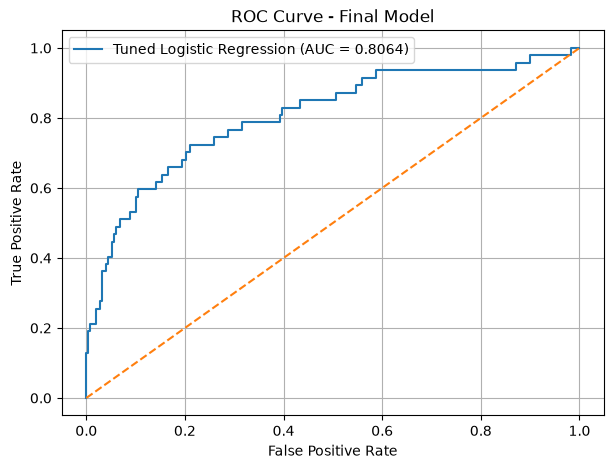

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)
import matplotlib.pyplot as plt
y_pred_final = final_model.predict(X_test_scaled)
y_prob_final = final_model.predict_proba(X_test_scaled)[:, 1]
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_prob_final)

print("FINAL MODEL PERFORMANCE")
print("=======================")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Tuned Logistic Regression (AUC = {final_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.grid()
plt.show()

### Final Model Evaluation

The selected tuned Logistic Regression model is evaluated on the test
dataset to measure its final predictive performance.

The evaluation includes Accuracy, Precision, Recall, F1-Score, Confusion
Matrix, and ROC-AUC.

These metrics provide a complete assessment of the model's ability to
predict employee Attrition on unseen test data.

In [ ]:


unseen_data = X_test.copy()


unseen_scaled = scaler.transform(unseen_data)


unseen_predictions = final_model.predict(unseen_scaled)


unseen_probabilities = final_model.predict_proba(unseen_scaled)[:, 1]


unseen_results = unseen_data.copy()

unseen_results["Predicted_Attrition"] = unseen_predictions
unseen_results["Attrition_Probability"] = unseen_probabilities


unseen_results["Predicted_Attrition"] = (
    unseen_results["Predicted_Attrition"]
    .map({0: "No", 1: "Yes"})
)

print("Unseen data prediction completed successfully!")
print("Number of unseen employees:", len(unseen_results))

print("\nPrediction Results:")
display(
    unseen_results[
        ["Predicted_Attrition", "Attrition_Probability"]
    ].head(10)
)

Unseen data prediction completed successfully!
Number of unseen employees: 294

Prediction Results:


,Predicted_Attrition,Attrition_Probability
1061,Yes,0.611983
891,No,0.068412
456,No,0.377302
922,No,0.045294
69,Yes,0.623341
1164,Yes,0.560722
406,No,0.134528
1330,No,0.199008
1232,No,0.064080
1311,No,0.474229


In [ ]:
new_employee = X_train.iloc[[0]].copy()
new_employee["Age"] = 30
new_employee["MonthlyIncome"] = 5000
new_employee["YearsAtCompany"] = 5
new_employee["YearsInCurrentRole"] = 3
new_employee["YearsSinceLastPromotion"] = 1
new_employee = new_employee[X_train.columns]
new_employee_scaled = scaler.transform(new_employee)
prediction = final_model.predict(new_employee_scaled)[0]
probability = final_model.predict_proba(new_employee_scaled)[0][1]

print("===================================")
print("      EMPLOYEE ATTRITION RESULT")
print("===================================")

if prediction == 1:
    print("Prediction : YES - Likely to Leave")
else:
    print("Prediction : NO - Likely to Stay")

print(f"Probability: {probability:.2%}")
print("===================================")

      EMPLOYEE ATTRITION RESULT
Prediction : NO - Likely to Stay
Probability: 9.03%


#  PREDICTION ON NEW UNSEEN EMPLOYEE DATA

The final trained model is used to predict employee Attrition for completely
new employee data.

The new employee's details are provided as input to the system. The same
feature engineering, encoding, and scaling procedures used during training
are applied automatically.

The processed input is then passed to the final tuned Logistic Regression
model.

The system returns the predicted Attrition status as either Yes or No.

In [ ]:
print(f"Probability of Attrition: {probability:.2%}")

if probability >= 0.50:
    print("Risk Level: HIGH")
else:
    print("Risk Level: LOW")

Probability of Attrition: 9.03%
Risk Level: LOW


### 

The final model also provides the probability of employee Attrition.

The probability represents the likelihood that the employee will leave the
organization.

A higher probability indicates a higher likelihood of Attrition.

# COMPLETE MACHINE LEARNING WORKFLOW

## 1. Data Loading
The employee dataset was loaded into a Pandas DataFrame for further
analysis and model development.

## 2. Data Understanding
The dataset was examined using shape, data types, statistical information,
and column analysis to understand the structure of the data.

## 3. Data Cleaning
Missing values and duplicate records were identified and handled to improve
the quality of the dataset.

## 4. Exploratory Data Analysis
The distribution of employee features and the Attrition target variable were
analyzed using statistical analysis and visualizations.

## 5. Correlation Analysis
Correlation analysis was performed to identify relationships between
numerical features and the Attrition target.

## 6. Feature Engineering
New meaningful features were created from existing features, including:
- CurrentRoleTenureRatio
- PromotionGapRatio
- TenureGroup

These features were created to provide additional information to the model.

## 7. Constant Feature Removal
Features containing only a single unique value were removed because they do
not provide useful information for prediction.

The constant features removed were:
- Over18
- StandardHours
- EmployeeCount

## 8. Categorical Feature Encoding
Categorical variables were converted into numerical form so that they could
be processed by machine learning algorithms.

TenureGroup was encoded using an ordered numerical representation.

## 9. Train-Test Split
The dataset was divided into training and testing sets.

Training data shape: (1176, 47)
Testing data shape: (294, 47)

The training data was used to train the models, while the test data was kept
unseen during training for final evaluation.

## 10. Class Imbalance Analysis
The distribution of the Attrition target classes was checked.

Since the target classes were imbalanced, balancing was performed only on the
training data to avoid data leakage.

## 11. Data Balancing
The training data was balanced so that the machine learning models could
better learn the minority Attrition class.

The test dataset was not balanced because it must represent unseen real-world
data.

## 12. Feature Scaling
StandardScaler was applied to numerical features.

The scaler was fitted only on the training data and then used to transform
both training and testing data.

## 13. Model Training
Five machine learning classification models were trained:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)
5. Naive Bayes

## 14. Model Evaluation
The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score

The results were compared to identify the best-performing model.

## 15. Model Comparison
The initial model comparison showed that Logistic Regression provided the
best overall F1-Score among the five models.

## 16. Hyperparameter Tuning
GridSearchCV was applied to Logistic Regression to find better
hyperparameter values.

Best Parameters:
- C = 0.01
- Solver = liblinear

Best Cross-Validation F1-Score:
- 0.7917

## 17. Tuned Model Evaluation
The tuned Logistic Regression model was evaluated on the unseen test data.

Performance improved from the original Logistic Regression model:

Accuracy:
0.7653 → 0.7721

Precision:
0.3750 → 0.3864

Recall:
0.7021 → 0.7234

F1-Score:
0.4889 → 0.5037

## 18. Final Model Selection
The tuned Logistic Regression model was selected as the final model because
it provided improved performance after hyperparameter tuning.

## 19. Unseen Employee Prediction
The final model was tested on new employee information.

The system processes the employee information using the same feature structure
and scaling procedure used during training.

The final model then predicts whether the employee is likely to leave the
organization.

Prediction:
- Attrition = YES → Employee is likely to leave
- Attrition = NO → Employee is likely to stay

## 20. Prediction Probability
The model also provides the probability of Attrition.

A higher probability indicates a higher likelihood that the employee may
leave the organization.

## 21. Model Saving
The final trained model and StandardScaler were saved using Joblib.

Saved files:
- final_attrition_model.pkl
- attrition_scaler.pkl

These files can be loaded later during deployment without retraining the
model.


